In [1]:
import notebook_dropdowns
notebook_dropdowns.helper()

HTML(value="\n    <p> <b style='color:black'> List of available commands for selecting geographic sites for an…

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import pyfabm
import os
from dask.diagnostics import ProgressBar
import warnings
import gc
import datetime
from contextlib import redirect_stdout
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import netCDF4
import matplotlib as mpl
from PIL import Image
import folium
import io
import base64
from branca.colormap import linear

In [3]:
from datacube import Datacube
dc = Datacube()
dc.list_products()

,name,description,license,default_crs,default_resolution
name,,,,,
cmems_chl_tur,cmems_chl_tur,CMEMS NWS BGC high-resolution L3 NRT daily mos...,proprietary,EPSG:4326,"Resolution(x=0.001, y=-0.001)"
cmems_poc,cmems_poc,CMEMS L4 3D BGC monthly climatology of particu...,proprietary,EPSG:4326,"Resolution(x=0.25, y=-0.25)"
cmems_sss,cmems_sss,CMEMS L4 multi-sensor sea surface salinity on ...,proprietary,EPSG:4326,"Resolution(x=0.125, y=-0.125)"
s3_olci_chl,s3_olci_chl,Sentinel-3 OLCI Level-2 Water Full Resolution ...,proprietary,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_slstr_sst,s3_slstr_sst,Sentinel-3 SLSTR Level-2 sea surface temperatu...,proprietary,EPSG:4326,"Resolution(x=0.01, y=-0.01)"
sentinel_2_ard,sentinel_2_ard,Sentinel-2 Analysis Ready Data (ARD) from the ...,None,EPSG:27700,"Resolution(x=10, y=-10)"


In [4]:
# initialization of site selection #
date_select = notebook_dropdowns.date_selection()

HTML(value='<b style=\'color:#1a2172\'> Use the calendars below to set a start date and an end date for analys…

DatePicker(value=None, description='Start date', layout=Layout(width='40%'), step=1, style=DescriptionStyle(de…

DatePicker(value=None, description='End date', layout=Layout(width='40%'), step=1, style=DescriptionStyle(desc…

Button(description='Reset', style=ButtonStyle())

HTML(value="<b style='color:#1a2172'> Start date: </b> Not set <b style='color:#1a2172'> &nbsp; End date: </b>…

In [5]:
# fetch selected dates
start_date, end_date = notebook_dropdowns.date_selected()
start_date, end_date

('2021-01-01', '2021-12-31')

In [6]:
# initialization of site selection #
polygon_select = notebook_dropdowns.area_selection()

HTML(value="<b style='color:#1a2172'> Use the dropdown menu below to select areas or sites for analysis <p> Us…

Dropdown(description='Area Selection Type', layout=Layout(width='40%'), options=('1. DRAW AREA', '2. USER UPLO…

Dropdown(description='Filter dataset or select all', layout=Layout(width='40%'), options=('lysekil boundary', …

Dropdown(description='OPTIONAL - Select a site', layout=Layout(width='40%'), options=('Lysekil_Boundary',), st…

Button(description='Reset', style=ButtonStyle())

In [7]:
#  map to select or draw a site
notebook_dropdowns.map_and_select_area(polygon_select)

Generating Interactive Map ...


IntProgress(value=0)

HTML(value="<b style='color:#1a2172'> After drawing area of interest on the map, wait for 'Selected Area:' con…

In [8]:
#  visualize selected option (add loading bar)
notebook_dropdowns.visualize_selected_area()

HTML(value="<b style='color:#1a2172'> No area selected. </b><br>")

In [10]:
#  print selected area bbox
# bbox = notebook_dropdowns.polygon_selected_tobbox()

bbox = (11.336505, 58.244635, 11.489554, 58.325851)
bbox

(11.336505, 58.244635, 11.489554, 58.325851)

In [11]:
# # Load data for May - August 2021
min_lon, min_lat, max_lon, max_lat = bbox

# Define resolution
resolution = 0.003   # use the lowest resolution in the dataset collection

dask_chunks={'time': -1}
# Define time range
time_range = (start_date, end_date)
time_horizon     = pd.date_range(start=start_date, end=end_date, freq='1d')
time_horizon_len = len(time_horizon)
print(f"Simulation period: {time_horizon[0].date()} → {time_horizon[-1].date()}  ({time_horizon_len} days)")
time_horizon_len

Simulation period: 2021-01-01 → 2021-12-31  (365 days)


365

In [12]:
from extract_filled_grid import load_filled_grid

combined_data = load_filled_grid(
    bbox=bbox,
    time_range=time_range,
    # resolution=0.125,
    resolution=resolution,
    verbose=True
)
combined_data

Loading SSS (cmems_sss)...
  SSS loaded in 1.2s
Loading SST (s3_slstr_sst)...
  SST loaded in 8.8s
Loading CHL (cmems_chl_tur)...
  CHL loaded in 0.5s
Reference grid: 29 lat x 53 lon @ 0.003 deg
Daily horizon: 2021-01-01 -> 2021-12-31 (365 days)
Regridding each variable (gaps preserved as NaN)...
Computing regridded arrays...
  Compute done in 463.7s
Starting DINEOF gap-filling...
  Processing salinity...
    Data shape: 365 time steps x 1537 ocean points
    Initial coverage: 561005/561005 (100.00%)
    Cross-validation: 28050 points withheld (5.0%)
    Determining optimal number of EOF modes...
    Optimal number of modes: 3
    Starting DINEOF iterations (max: 100)...
    Converged at iteration 6 (CV-RMSE = 0.026449)
    Final coverage (ocean only): 100.00%
  Processing temperature...
    Data shape: 365 time steps x 1027 ocean points
    Initial coverage: 27835/374855 (7.43%)
    Cross-validation: 1391 points withheld (5.0%)
    Determining optimal number of EOF modes...
    Optima

<xarray.Dataset> Size: 7MB
Dimensions:      (time: 365, latitude: 29, longitude: 53)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-01 2021-01-02 ... 2021-12-31
  * latitude     (latitude) float64 232B 58.33 58.33 58.32 ... 58.25 58.25 58.24
  * longitude    (longitude) float64 424B 11.34 11.34 11.34 ... 11.49 11.49
    spatial_ref  int32 4B 4326
Data variables:
    salinity     (time, latitude, longitude) float32 2MB 29.0 29.0 ... 29.81
    temperature  (time, latitude, longitude) float32 2MB nan nan nan ... nan nan
    chlorophyll  (time, latitude, longitude) float32 2MB nan nan nan ... nan nan
    ocean_mask   (latitude, longitude) bool 2kB False False ... False False

In [13]:
ds_daily = combined_data
ds_daily = combined_data.rename({"chlorophyll": "Chl"})
ds_daily

<xarray.Dataset> Size: 7MB
Dimensions:      (time: 365, latitude: 29, longitude: 53)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-01 2021-01-02 ... 2021-12-31
  * latitude     (latitude) float64 232B 58.33 58.33 58.32 ... 58.25 58.25 58.24
  * longitude    (longitude) float64 424B 11.34 11.34 11.34 ... 11.49 11.49
    spatial_ref  int32 4B 4326
Data variables:
    salinity     (time, latitude, longitude) float32 2MB 29.0 29.0 ... 29.81
    temperature  (time, latitude, longitude) float32 2MB nan nan nan ... nan nan
    Chl          (time, latitude, longitude) float32 2MB nan nan nan ... nan nan
    ocean_mask   (latitude, longitude) bool 2kB False False ... False False

In [14]:
INPUT_FILE = "gridded_input_ALL_STATES.nc"

In [15]:

# SAVE COMBINED DATACUBE TO NETCDF
print(f"Saving combined datacube to: {INPUT_FILE}")
print(f"Dataset info before saving:")
print(f"  Variables: {list(ds_daily.data_vars)}")
print(f"  Time steps: {len(ds_daily.time)}")
print(
    f"  Spatial extent: "
    f"lat {ds_daily.latitude.values.min():.3f} to {ds_daily.latitude.values.max():.3f}, "
    f"lon {ds_daily.longitude.values.min():.3f} to {ds_daily.longitude.values.max():.3f}"
)


# Remoe CF encoding attributes that xarray will recreate
ds_to_save = ds_daily.copy()
for attr in ["units", "calendar"]:
    ds_to_save.time.attrs.pop(attr, None)

# Clear any existing encoding that may conflict
ds_to_save.time.encoding = {}

# Compression settings
encoding = {
    var: {
        "zlib": True,
        "complevel": 4,
        "dtype": "float32",
    }
    for var in ds_to_save.data_vars
}

# Explicit encoding for the time coordinate
encoding["time"] = {
    "units": "days since 1970-01-01 00:00:00",
    "calendar": "proleptic_gregorian",
}


# Save dataset
ds_to_save.to_netcdf(
    INPUT_FILE,
    engine="h5netcdf",
    encoding=encoding,
    compute=True,
)

print(f"✓ Successfully saved to {INPUT_FILE}")
print(f"  File size: {os.path.getsize(INPUT_FILE) / 1024**2:.2f} MB")

Saving combined datacube to: gridded_input_ALL_STATES.nc
Dataset info before saving:
  Variables: ['salinity', 'temperature', 'Chl', 'ocean_mask']
  Time steps: 365
  Spatial extent: lat 58.245 to 58.329, lon 11.337 to 11.493
✓ Successfully saved to gridded_input_ALL_STATES.nc
  File size: 2.28 MB


In [16]:
# # if reading from outputonly
# INPUT_FILE = "gridded_input_ALL_STATES.nc"
# bbox = (11.309052, 58.240931, 11.462173, 58.318911)
# start_date, end_date = "2021-01-01", "2021-12-31"
# result_dataset = ds_out

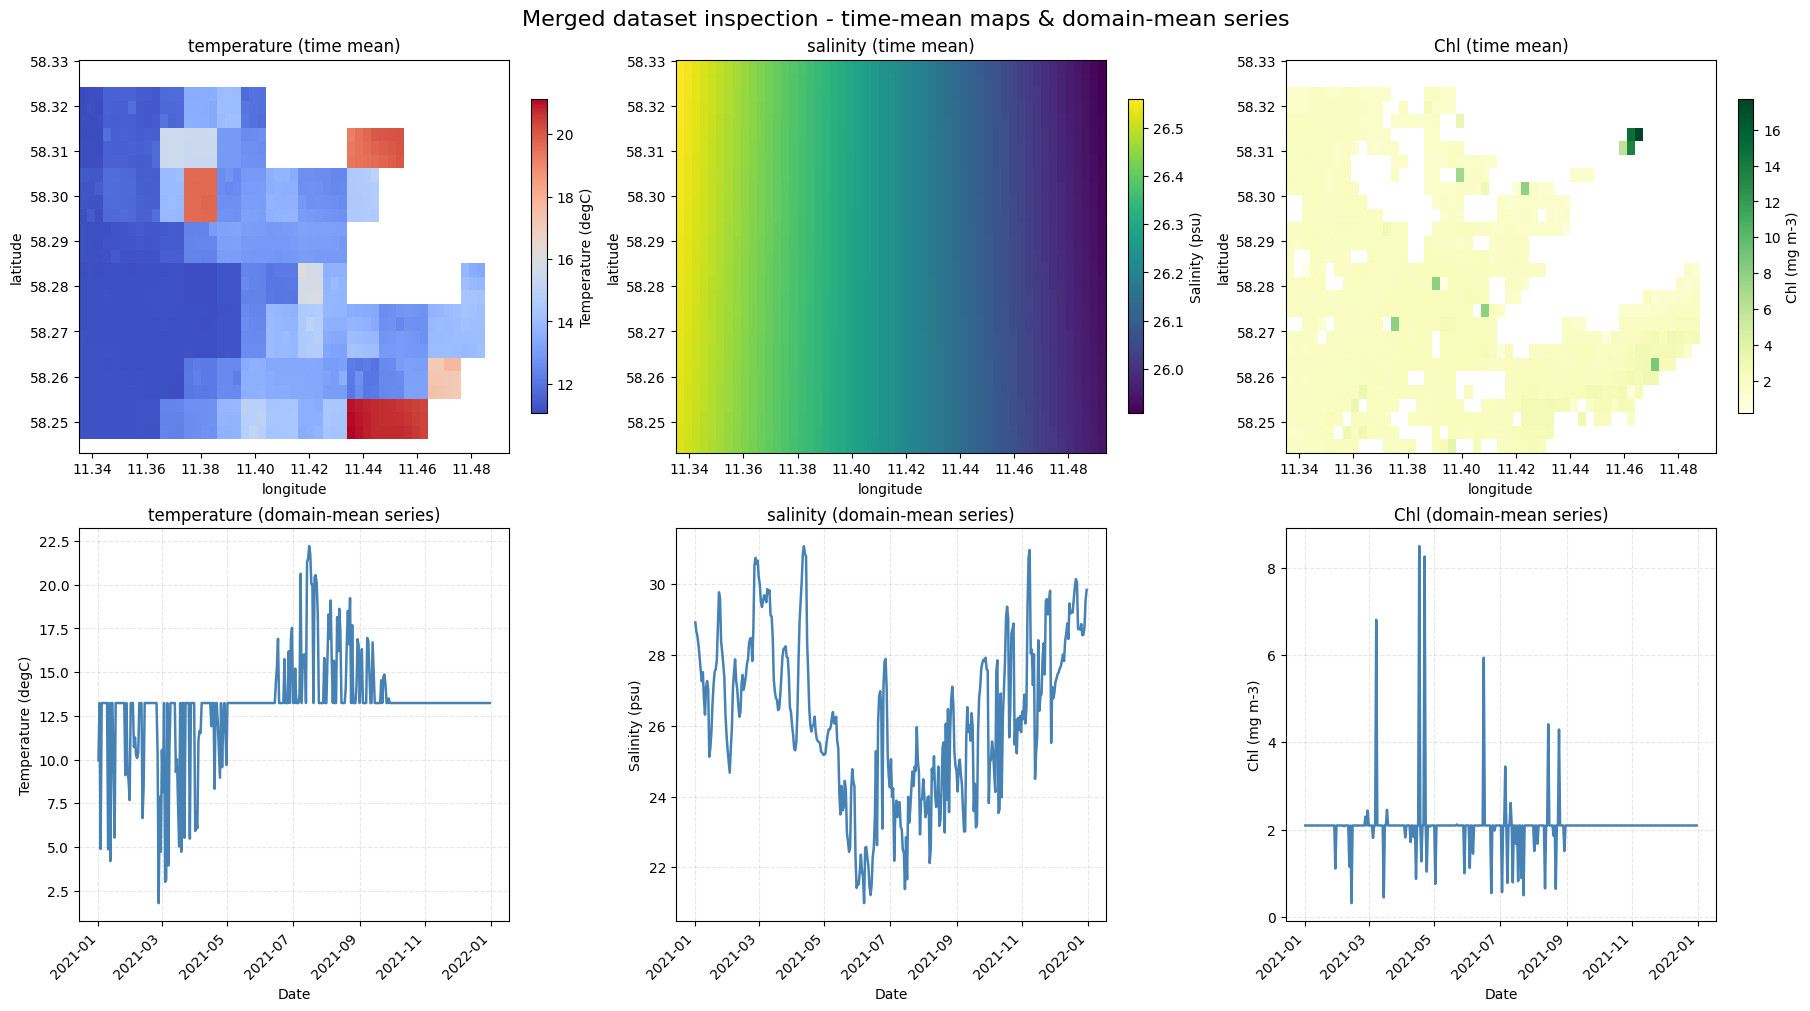

In [17]:
# ============================================================
# EXPLORATORY VISUALISATION OF MERGED DATA
# ============================================================
# Inspect the combined cube before running the model.
#   Top row    : spatial time-mean maps  (geographic pattern per variable)
#   Bottom row : domain-mean daily series (temporal variability per variable)

# ds_daily = combined_data

vars_to_plot = [
    ("temperature", "Temperature (degC)", "coolwarm"),
    ("salinity",    "Salinity (psu)",     "viridis"),
    ("Chl",  "Chl (mg m-3)",       "YlGn"),
]

if ds_daily is None or 'time' not in ds_daily.dims:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    for col, (var, label, cmap) in enumerate(vars_to_plot):
        ax_map, ax_ts = axes[0, col], axes[1, col]

        if var not in ds_daily:
            ax_map.text(0.5, 0.5, f"{var} not found", ha='center')
            ax_ts.text(0.5, 0.5, f"{var} not found", ha='center')
            continue

        da = ds_daily[var]

        # --- top: spatial time-mean map ---
        da.mean(dim='time').plot(
            ax=ax_map, cmap=cmap, add_colorbar=True,
            cbar_kwargs={'shrink': 0.8, 'label': label},
        )
        ax_map.set_title(f"{var} (time mean)")
        ax_map.set_xlabel("longitude")
        ax_map.set_ylabel("latitude")

        # --- bottom: domain-mean daily time series ---
        ts = da.mean(dim=['latitude', 'longitude'])
        ax_ts.plot(ds_daily['time'], ts, color='steelblue', lw=1.8)
        ax_ts.set_title(f"{var} (domain-mean series)")
        ax_ts.set_xlabel("Date")
        ax_ts.set_ylabel(label)
        ax_ts.grid(True, alpha=0.3, ls='--')
        for t in ax_ts.get_xticklabels():
            t.set_rotation(45)
            t.set_ha('right')

    plt.suptitle("Merged dataset inspection - time-mean maps & domain-mean series",
                 fontsize=16)
    # plt.savefig("ds_daily_inspection.png", dpi=150)
    plt.show()

In [18]:
# Prepare variables to plot
vars_to_show = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
available_vars = [v for v in vars_to_show if v in ds_daily]

if len(available_vars) == 0:
    print("No variables available in ds_daily to create folium map.")
else:
    lat_vals = ds_daily.latitude.values
    lon_vals = ds_daily.longitude.values
    lat_min, lat_max = float(lat_vals.min()), float(lat_vals.max())
    lon_min, lon_max = float(lon_vals.min()), float(lon_vals.max())
    bounds = [[lat_min, lon_min], [lat_max, lon_max]]
    center = [(lat_min + lat_max) / 2.0, (lon_min + lon_max) / 2.0]

    # Is latitude stored ascending (south -> north)?
    lat_ascending = bool(lat_vals[0] < lat_vals[-1])

    m = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

    def array_to_dataurl(arr2d, cmap_name='viridis', vmin=None, vmax=None):
        """2D array (lat x lon) -> PNG data URL.
           Folium maps image row 0 to the NORTH edge, so row 0 must be the
           northernmost latitude. We orient based on the actual lat ordering."""
        arr = np.array(arr2d, dtype=float)
        # Make row 0 == northernmost. If lats are ascending (row 0 = south),
        # flip vertically; if already descending (row 0 = north), leave as is.
        if lat_ascending:
            arr = np.flipud(arr)
        mask = np.isnan(arr)

        if vmin is None:
            vmin = np.nanpercentile(arr, 2)
        if vmax is None:
            vmax = np.nanpercentile(arr, 98)
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
            vmin, vmax = np.nanmin(arr), np.nanmax(arr)
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
                vmax = vmin + 1.0

        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
        cmap = mpl.colormaps[cmap_name]          # replaces deprecated mpl.cm.get_cmap
        mapped = cmap(norm(arr))                  # RGBA float [0,1]
        mapped[..., 3][mask] = 0.0                # transparent where NaN

        rgba8 = (mapped * 255).astype(np.uint8)
        im = Image.fromarray(rgba8, mode='RGBA')
        bio = io.BytesIO()
        im.save(bio, format='PNG')
        b64 = base64.b64encode(bio.getvalue()).decode('ascii')
        return f"data:image/png;base64,{b64}"

    var_cmaps = {
        'temperature': 'viridis', 'salinity': 'plasma', 'Chl': 'YlGn',
        'POC': 'YlOrBr', 'POM': 'OrRd', 'TPM': 'inferno',
    }

    first_added = False
    for var in available_vars:
        try:
            da_mean = ds_daily[var].mean(dim='time').values
            if da_mean.ndim != 2:
                da_mean = np.squeeze(da_mean)
                if da_mean.ndim != 2:
                    print(f"Skipping {var}: not 2D after squeeze")
                    continue

            cmap = var_cmaps.get(var, 'viridis')
            vmin = np.nanpercentile(da_mean, 2)
            vmax = np.nanpercentile(da_mean, 98)
            data_url = array_to_dataurl(da_mean, cmap_name=cmap, vmin=vmin, vmax=vmax)

            folium.raster_layers.ImageOverlay(
                name=var, image=data_url, bounds=bounds,
                opacity=0.8 if not first_added else 1.0,
                interactive=True, cross_origin=False, zindex=1,
            ).add_to(m)
            first_added = True

            try:
                lc = linear.__getattribute__(cmap).scale(
                    float(np.nanmin(da_mean)), float(np.nanmax(da_mean)))
                lc.caption = f"{var} (time mean)"
                lc.add_to(m)
            except Exception:
                pass
        except Exception as e:
            print(f"Failed to add overlay for {var}: {e}")

    folium.LayerControl(collapsed=False).add_to(m)

    js = """
    <script>
    function makeOverlaysRadio(){
      var lc = document.getElementsByClassName('leaflet-control-layers')[0];
      if(!lc) { setTimeout(makeOverlaysRadio, 200); return; }
      var inputs = lc.querySelectorAll('input');
      for(var i=0; i<inputs.length; i++){
        if(inputs[i].type === 'checkbox'){
          inputs[i].type = 'radio';
          inputs[i].name = 'overlayGroup';
        }
      }
    }
    setTimeout(makeOverlaysRadio, 500);
    </script>
    """
    from folium import Element
    m.get_root().html.add_child(Element(js))
    print("Folium map built.")

try:
    display(m)
except Exception:
    pass

Folium map built.


In [19]:
# ============================================================
# RECHUNK FOR OPTIMAL DASK PERFORMANCE
# ============================================================
# After subsetting and interpolation, Dask's internal chunk
# boundaries may be irregular. Rechunking reorganises them into
# uniform tiles:
#   time: -1  -> one chunk for the full time axis (required;
#               ShellSIM cannot be split along time)
#   lat: 80, lon: 110 -> spatial tile footprint
# After rechunking each Dask task processes one complete tile
# with no overlap, minimising scheduler overhead.
#
# RAM tip: if you encounter MemoryErrors, halve lat/lon chunk
# sizes. Each chunk ~ lat * lon * time_steps * 8 bytes * n_vars.

# Rechunk for optimal performance
# After all the merging and interpolating, Dask's chunks can get fragmented, rechunk so every Dask task receives 
# a data chunk of the exact size


# large_dataset
# dataset_chunk = {'time': -1, 'latitude': 18, 'longitude': 35}

# small dataset
dataset_chunk = {'time': -1, 'latitude': -1, 'longitude': -1}

print("Rechunking dataset for optimal performance")
# Force Dask backing AND explicit spatial tiling.
# time stays as ONE chunk (ShellSIM cannot be split along time);
# latitude/longitude are tiled so each Dask task = one spatial tile.
# ds_daily = ds_daily.chunk({
#     'time': -1,        # whole time axis (required — ShellSIM can't split time)
#     'latitude': 18,    # 35 -> 2 tiles (18 + 17)
#     'longitude': 35,   # 69 -> 2 tiles (35 + 34)
# })

# if  whole cube is ~30 MB, one tile is also perfectly fine and simplest:
ds_daily = ds_daily.chunk(dataset_chunk)

print("Rechunked dataset")
print("Is dask-backed:", bool(ds_daily.chunks))   # should print True
print(ds_daily.chunks)

# and gives 4 roughly equal tiles.




Rechunking dataset for optimal performance
Rechunked dataset
Is dask-backed: True
Frozen({'time': (365,), 'latitude': (29,), 'longitude': (53,)})


# ShellSIM model wrapper   
takes a 1D numpy array (time-series for one pixel) as input. run entire for loop (time-stepping) and return a 1D numpy array of the result ( eg soft tissue energy time-series). Then Apply in Parallel, using xr.apply_ufunc to apply wrapper function to the gridded data. tell apply_ufunc that the "core dimension" is time, which instructs it to parallelize over all other dimensions (lat, lon)

In [20]:
PYFABM_MODEL_CONFIG="/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/notebook_dropdowns/final_working_versions/partial_fabm.yaml"

In [21]:
# ============================================================
# SHELLSIM MODEL CONSTANTS AND WRAPPER FUNCTION
# ============================================================
# N_STATES  = 11 : internal state variables integrated by pyfabm
# N_DIAGS   =  2 : diagnostic outputs (TFW, SL) — from pyfabm
#                  diagnostic_variables, NOT part of model.state
# N_OUTPUTS = 13 : total rows returned per pixel (states + diags)
#
# VARIABLE_NAMES order MUST exactly match the row order filled
# inside the time loop: rows 0–10 = 11 state variables,
# row 11 = TFW, row 12 = SL.
#
# run_fabm_at_point_full (fixes applied):
#   1. Uses len(T_ts) instead of outer-scope time_horizon_len so
#      the function is self-contained and safe in Dask workers.
#   2. Clamps food concentrations (Chl/POC/POM/TPM) to >= 0.
#      Negative concentrations from bad/fake data cause forward-
#      Euler to diverge within a few steps.
#   3. Updates number_of_days_since_start_of_the_year every step
#      so seasonal physiology is correct across the full period.
#   4. redirect_stdout now covers the ENTIRE function body so
#      all FABM print output goes to the log file, not stdout.
# ============================================================

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"

N_STATES  = 8   # pyfabm internal state variables (model.state[:] length)
N_DIAGS   = 2    # diagnostic outputs: TFW (row 11), SL (row 12)
N_OUTPUTS = N_STATES + N_DIAGS  # = 13 — total rows returned per pixel

# Authoritative names list — length must equal N_OUTPUTS (13).
# Method 2 imports this directly; do NOT redefine STATE_NAMES elsewhere.
VARIABLE_NAMES = [
    'soft_tissue_energy', 'shell_energy', 
    'aging', 
    'C1',
    'C2', 
    'C3',
    'Chl_state', 
    # 'POC_state', 
    # 'POM_state', 
    # 'TPM_state',
    
    'O2',  # rows 0–10
    'TFW', 
    'SL'# rows 11–12
]

assert len(VARIABLE_NAMES) == N_OUTPUTS, (
    f"VARIABLE_NAMES has {len(VARIABLE_NAMES)} entries but N_OUTPUTS={N_OUTPUTS}"
)


def run_fabm_at_point_full(T_ts, S_ts, Chl_ts,
                           # POC_ts=None, POM_ts=None, TPM_ts=None,
                           log_filename=None
                          ):

    """
    Runs the FABM/ShellSIM time-loop for a single spatial pixel.

    Parameters
    ----------
    T_ts, S_ts          : 1-D float arrays, length n_steps
        Temperature (°C) and practical salinity (PSU) time series.
    Chl_ts, POC_ts,
    POM_ts, TPM_ts      : 1-D float arrays, length n_steps
        Food-variable time series (mg m-3).  Values < 0 are clamped
        to 0 before being passed to the model (negative concentrations
        are unphysical and cause forward-Euler divergence).
    log_filename        : str
        Path to the append-mode log file that receives all FABM
        print/diagnostic output (keeps Jupyter stdout clean).

    Returns
    -------
    numpy.ndarray, shape (N_OUTPUTS=13, n_steps)
        Rows  0–10 : pyfabm state variables (model.state[:])
        Row  11    : TFW  diagnostic [g]
        Row  12    : Shell Length diagnostic [cm]
        All-NaN on land pixels or when any input is NaN / non-finite.
    """
    # ── n_steps is taken directly from the input arrays, NOT from the
    #    outer-scope time_horizon_len, so this function is safe to call
    #    from Dask workers that were serialised with a stale closure. ──
    n_steps = len(T_ts)




    # ── Guard: reject land / missing-data pixels ────────────────────
    all_inputs = [T_ts, S_ts, Chl_ts,
                  # POC_ts, POM_ts, TPM_ts
                 
                 ]
    if any(np.any(np.isnan(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, n_steps), np.nan)
    if not all(np.all(np.isfinite(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, n_steps), np.nan)

    # ── Clamp food concentrations to physically valid range ─────────
    # Negative concentrations are unphysical (artefacts of linear
    # interpolation or fake test data).  Passing them to the model
    # causes the forward-Euler integration to diverge within a few
    # steps, producing NaN or runaway values for the entire run.
    Chl_ts  = np.maximum(Chl_ts,  0.0)
    # POC_ts  = np.maximum(POC_ts,  0.0)
    # POM_ts  = np.maximum(POM_ts,  0.0)
    # TPM_ts  = np.maximum(TPM_ts,  0.0)

    try:
        # ── redirect_stdout covers the FULL function body so that
        #    pyfabm print output during both init AND getRates() goes
        #    to the log file rather than flooding Jupyter output. ────
        with open(log_filename, 'a') as f_log:
            with redirect_stdout(f_log):
                    
                model = pyfabm.Model(PYFABM_MODEL_CONFIG)

                # ── Static (time-invariant) dependencies ────────────
                model.cell_thickness = 1.0
                model.dependencies["seeding_rate"].value  = 0.0
                model.dependencies["harvest_ratio"].value = 0.0
                model.dependencies["current_speed"].value = 1.0
                model.dependencies["air_exposure"].value  = 0.0

                # ── Initialise from day-0 forcing values ─────────────
                model.dependencies["temperature"].value        = float(T_ts[0])
                model.dependencies["practical_salinity"].value = float(S_ts[0])
                model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                    pd.Timestamp(time_horizon[0]).dayofyear
                )
                model.findStateVariable('Chl1/Chl').value = float(Chl_ts[0])
                # model.findStateVariable('POC1/POC').value = float(POC_ts[0])
                # model.findStateVariable('POM1/POM').value = float(POM_ts[0])
                # model.findStateVariable('TPM1/TPM').value = float(TPM_ts[0])

                if not model.start():
                    raise RuntimeError("FABM model failed to start internally.")
                
                if model.state[:].size != N_STATES:
                    raise ValueError(   # not RuntimeError → not caught below → surfaces loudly
                        f"YAML produces {model.state[:].size} states but N_STATES={N_STATES} "
                        f"— check which prey modules are active in partial_fabm.yaml"
                    )

                # ── Output array ─────────────────────────────────────
                outputs = np.zeros((N_OUTPUTS, n_steps))

                for nd in range(n_steps):
                    # ── Update day-of-year (drives seasonal physiology) ──
                    model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                        pd.Timestamp(time_horizon[nd]).dayofyear
                    )

                    # ── Update environmental forcings ────────────────
                    model.dependencies["temperature"].value        = float(T_ts[nd])
                    model.dependencies["practical_salinity"].value = float(S_ts[nd])
                    model.findStateVariable('Chl1/Chl').value      = float(Chl_ts[nd])
                    # model.findStateVariable('POC1/POC').value      = float(POC_ts[nd])
                    # model.findStateVariable('POM1/POM').value      = float(POM_ts[nd])
                    # model.findStateVariable('TPM1/TPM').value      = float(TPM_ts[nd])

                    # ── Forward-Euler step (same as original 1-D notebook) ──
                    state_rates = model.getRates()
                    model.state[:] += state_rates * 86400.0

                    # ── Guard: catch state blow-up immediately ────────────
                    # If any state variable is NaN or Inf (e.g. from a cube-
                    # root / log of a negative energy reserve when the oyster
                    # starves), pyfabm silently propagates bad values for all
                    # remaining steps without raising an exception.
                    # Detect it here, fill remaining outputs with NaN, and
                    # break — this preserves the valid data already computed
                    # up to this timestep rather than discarding it.
                    if not np.all(np.isfinite(np.array(model.state[:]))):
                        outputs[:, nd:] = np.nan
                        break

                    # ── Store state variables (rows 0–10) ────────────
                    outputs[:N_STATES, nd] = np.array(model.state[:])

                    # ── Store diagnostics (rows 11–12) ───────────────
                    outputs[N_STATES,     nd] = model.diagnostic_variables['Oyster/TFW'].value
                    outputs[N_STATES + 1, nd] = model.diagnostic_variables['Oyster/Shell_Length'].value

        return outputs  # shape (N_OUTPUTS=13, n_steps)

    except RuntimeError:
        warnings.warn(f"FABM failed to start: {pyfabm.getError()}")
        return np.full((N_OUTPUTS, n_steps), np.nan)

    except Exception as e:
        warnings.warn(f"FABM error at pixel: {str(e)}")
        return np.full((N_OUTPUTS, n_steps), np.nan)

## Most optimal processing method:  parallelize over the spatial dimensions (latitude, longitude) using xarray.apply_ufunc.  
chunking only the spatial dimensions (latitude and longitude) tells Dask to split the map into tiles, but keep the full time series for each pixel intact.

In [22]:
time_horizon_len = ds_daily.time.size
output_file_name = "gridded_oyster_output_ALL_STATES_batched.nc"

In [23]:
# ============================================================
# METHOD 1 —  RUN For Small area 
# ============================================================

# ============================================================
# MATERIALISE FORCING INPUTS BEFORE GOING DISTRIBUTED
# ============================================================
# datacube.load returns arrays whose Dask graph holds lazy
# rasterio/odc reader objects (a lambda + a weakref). The default
# threaded scheduler never pickles them, but dask.distributed MUST
# pickle the graph to ship it to worker PROCESSES -> that is the
# "Can't pickle ... <lambda>" / "cannot pickle weakref" crash.
#
# Computing here — BEFORE the Client is created, so it runs on the
# local threaded scheduler — turns those readers into plain numpy.
# We then re-chunk so apply_ufunc(dask='parallelized') still tiles
# over latitude/longitude. The graph shipped to workers is now just
# numpy data + the (importable) wrapper function = fully picklable.

# try:
#     client.close()
# except NameError:
#     pass

# ds_daily = (
#     ds_daily[['temperature', 'salinity', 'Chl']]
#     .drop_vars('spatial_ref', errors='ignore')
#     .compute()                          # no client active now -> local scheduler
#     .chunk({'time': -1, 'latitude': 18, 'longitude': 35})
# )
# print('Inputs materialised and rechunked:', dict(ds_daily.chunks))

# force the local scheduler on this compute
ds_daily = (
    ds_daily[['temperature', 'salinity', 'Chl']]
    .drop_vars('spatial_ref', errors='ignore')
    .compute(scheduler='synchronous')   # <-- bypass the already-active distributed Client
    .chunk(dataset_chunk)
)
dataset_chunks = dict(ds_daily.chunks)

preffered_chunksize = (1, dataset_chunks['latitude'][0], dataset_chunks['longitude'][0])
print('Inputs materialised and rechunked:', dataset_chunks)
print('Chunksize:', preffered_chunksize)



Inputs materialised and rechunked: {'time': (365,), 'latitude': (29,), 'longitude': (53,)}
Chunksize: (1, 29, 53)


In [24]:
# ============================================================
# METHOD 1: APPLY_UFUNC — PARALLEL SPATIAL APPLICATION
# ============================================================
# xr.apply_ufunc applies run_fabm_at_point_full across every
# (lat, lon) pixel in parallel via Dask.
#
# Key settings:
#   input_core_dims=[['time']]*6 : time is the 'core' dimension
#     consumed by the function; Dask parallelises over lat x lon.
#   output_core_dims=[['state','time']] : wrapper returns (13,T).
#   vectorize=True : loops pixel-by-pixel (needed for pyfabm).
#   dask='parallelized' : each spatial chunk becomes a Dask task.
#
# --- WHY dask.distributed WITH PROCESSES ---
# pyfabm holds C-level global state and is NOT thread-safe.
# Using process-based workers gives each worker its own memory
# space and its own pyfabm instance, preventing race conditions.
# n_workers=4, threads_per_worker=2 gives 8 concurrent slots;
# adjust n_workers to match your CPU count (cpu_count // 2).

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"


from dask.distributed import Client

# Start process-based local cluster (thread-safe for pyfabm)
# IMPORTANT: threads_per_worker MUST be 1.
# pyfabm has C-level global state that is NOT thread-safe.
# Two concurrent pyfabm instances in the SAME process (threads)
# will corrupt each other's model state silently.
client = Client(n_workers=4, threads_per_worker=1, processes=True)
print('Dask dashboard:', client.dashboard_link)

print('Setting up parallel computation with apply_ufunc ...')



# run ONCE before the dask/apply_ufunc call, not inside the wrapper
_m = pyfabm.Model(PYFABM_MODEL_CONFIG)
assert _m.state[:].size == N_STATES, (
    f"YAML produces {_m.state[:].size} states but N_STATES={N_STATES} "
    f"— check which prey modules are active in partial_fabm.yaml"
)
del _m


result_full = xr.apply_ufunc(
    run_fabm_at_point_full,
    ds_daily['temperature'],   
    ds_daily['salinity'],
    ds_daily['Chl'],
    # ds_daily['POC'],
    # ds_daily['POM'],
    # ds_daily['TPM'],
    input_core_dims=[['time']] * 3,
    output_core_dims=[['state', 'time']],
    exclude_dims=set(('time',)),
    dask='parallelized',
    vectorize=True,
    output_dtypes=[float],
    kwargs={'log_filename': RUN_LOG_FILENAME},
    dask_gufunc_kwargs={
        'allow_rechunk': True,
        'output_sizes': {'state': N_OUTPUTS, 'time': time_horizon_len}
    }
)

# Restore coordinate labels on the output dimensions
result_full = result_full.assign_coords(time=time_horizon)
result_full = result_full.assign_coords(state=VARIABLE_NAMES)

# Promote 'state' coordinate slices into separate Dataset variables
result_dataset = result_full.to_dataset(dim='state')

# Attach CF-convention metadata attributes
result_dataset['soft_tissue_energy'].attrs = {'units': 'J', 'long_name': 'Soft Tissue Energy'}
result_dataset['shell_energy'].attrs = {'units': 'J', 'long_name': 'Shell Energy'}
result_dataset['aging'].attrs = {'units': 'days', 'long_name': 'Aging'}
result_dataset['C1'].attrs = {'units': '', 'long_name': 'C1 State Variable'}
result_dataset['C2'].attrs = {'units': '', 'long_name': 'C2 State Variable'}
result_dataset['C3'].attrs = {'units': '', 'long_name': 'C3 State Variable'}
result_dataset['Chl_state'].attrs = {'units': 'mg/m3', 'long_name': 'Chlorophyll State'}
# result_dataset['POC'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Carbon State'}
# result_dataset['POM'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Matter State'}
# result_dataset['TPM'].attrs = {'units': 'mg/m3', 'long_name': 'Total Particulate Matter State'}
result_dataset['O2'].attrs = {'units': 'mg/L', 'long_name': 'Oxygen State'}
result_dataset['SL'].attrs = {'units': 'cm', 'long_name': 'Shell Length'}
result_dataset['TFW'].attrs = {'units': 'g', 'long_name': 'Total Fresh Weight'}

print('\nTask graph built. Result Dataset has 13 variables.')
print(result_dataset)

Dask dashboard: http://127.0.0.1:8787/status
Setting up parallel computation with apply_ufunc ...
Initializing Oyster...
   model type: shellsim_base
   initialization succeeded.
Initializing Chl1...
   model type: shellsim/prey
   initialization succeeded.
Initializing O2...
   model type: bb/passive
   initialization succeeded.

Task graph built. Result Dataset has 13 variables.
<xarray.Dataset> Size: 45MB
Dimensions:             (latitude: 29, longitude: 53, time: 365)
Coordinates:
  * latitude            (latitude) float64 232B 58.33 58.33 ... 58.25 58.24
  * longitude           (longitude) float64 424B 11.34 11.34 ... 11.49 11.49
  * time                (time) datetime64[ns] 3kB 2021-01-01 ... 2021-12-31
Data variables:
    soft_tissue_energy  (latitude, longitude, time) float64 4MB dask.array<chunksize=(29, 53, 365), meta=np.ndarray>
    shell_energy        (latitude, longitude, time) float64 4MB dask.array<chunksize=(29, 53, 365), meta=np.ndarray>
    aging               (latitu

# Run computation and Save  
Call .compute() or .to_netcdf() on the result. This triggers Dask to execute the parallel computation and write the final 3D output file.

In [25]:
# ============================================================
# TRIGGER COMPUTATION AND SAVE WITH ZLIB COMPRESSION
# ============================================================
# Calling .to_netcdf() on the Dask-backed Dataset triggers all
# queued tasks and streams results directly to disk so peak RAM
# stays near: one_chunk_size x num_workers.

# encoding: enables zlib (deflate) compression at level 4 for
# all 13 output variables. Level 4 gives a good trade-off:
# typically 3-5x size reduction vs uncompressed with negligible
# read-time overhead. chunksizes=(1,65,92) makes single time-
# slice reads contiguous on disk.


# ========================= code to run ===========================

# Build compression encoding dict for all 13 output variables
# _compress_enc = {'zlib': True, 'complevel': 4, 'chunksizes': (1, 65, 92)}
_compress_enc = {'zlib': True, 'complevel': 4, 'chunksizes': preffered_chunksize}

encoding = {var: _compress_enc for var in VARIABLE_NAMES}

print('Now running dask computation ...')
with ProgressBar():
    result_dataset.to_netcdf(output_file_name, compute=True, encoding=encoding)

print(f'****** SUCCESS: Results saved to {output_file_name} *******')

# Release distributed workers when done
client.close()

Now running dask computation ...
****** SUCCESS: Results saved to gridded_oyster_output_ALL_STATES_batched.nc *******


In [26]:
# ============================================================
# OPTIONAL MEMORY CLEANUP
# ============================================================
# Uncomment these lines after saving to free RAM, especially
# important if continuing to Method 2 or the analysis sections
# below on a machine with limited memory.

# # Clean up
# del ds_poc  
# del ds_sal
# del ds_temp
# del ds_chl
# del ds_pom
# del ds_tpm
# del ds_daily, result_sten
# gc.collect()

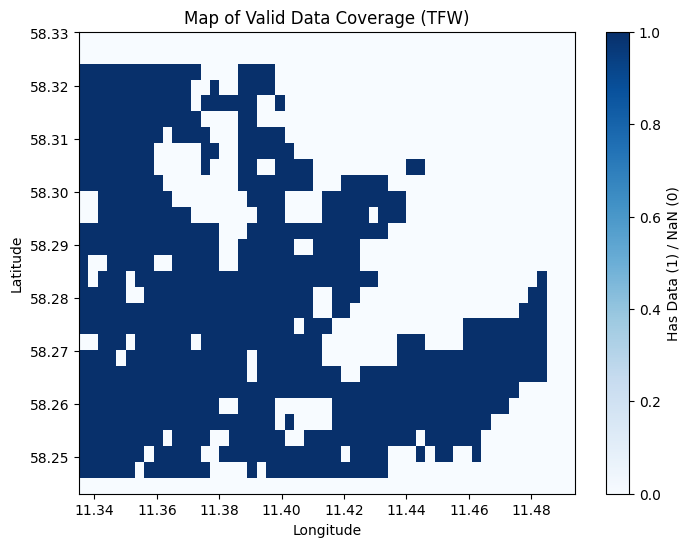


Examine the map above to visually pick a coordinate (blue area) to plot.


In [27]:
# ============================================================
# DATA COVERAGE MAP
# ============================================================
# Creates a spatial map showing which pixels contain valid
# (non-NaN) model output vs which are all-NaN (land or where
# all inputs were missing). Blue pixels = valid model output;
# white pixels = no data. Use this map to identify regions
# suitable for aquaculture analysis.

# 1. Create a boolean map: True if a pixel has ANY non-NaN data over time
#    .any(dim='time') collapses the time dimension, leaving only (lat, lon)
data_coverage = ~result_dataset['TFW'].isnull().all(dim='time')

# 2. Plot the coverage map
plt.figure(figsize=(8, 6))
# We use .plot() from xarray directly for simplicity
data_coverage.plot(
    cmap='Blues', 
    cbar_kwargs={'label': 'Has Data (1) / NaN (0)'}
)
plt.title('Map of Valid Data Coverage (TFW)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("\nExamine the map above to visually pick a coordinate (blue area) to plot.")

In [28]:
# ============================================================
# SINGLE-POINT TIME SERIES PLOTS
# ============================================================
# Reads directly from the saved netCDF output file so results
# are persistent across kernel restarts and cover all batches.
# result_dataset is NOT used here — it only holds the last
# tile in memory and is discarded after the batch loop.
# ============================================================

OUTPUT_FILE = "gridded_oyster_output_ALL_STATES_batched.nc"
# Mask sentinel error values (-99) and non-finite values written
# by ShellSIM on pixels that failed internally.
ds_out = xr.open_dataset(OUTPUT_FILE)
ds_out


<xarray.Dataset> Size: 45MB
Dimensions:             (latitude: 29, longitude: 53, time: 365)
Coordinates:
  * latitude            (latitude) float64 232B 58.33 58.33 ... 58.25 58.24
  * longitude           (longitude) float64 424B 11.34 11.34 ... 11.49 11.49
  * time                (time) datetime64[ns] 3kB 2021-01-01 ... 2021-12-31
Data variables:
    soft_tissue_energy  (latitude, longitude, time) float64 4MB ...
    shell_energy        (latitude, longitude, time) float64 4MB ...
    aging               (latitude, longitude, time) float64 4MB ...
    C1                  (latitude, longitude, time) float64 4MB ...
    C2                  (latitude, longitude, time) float64 4MB ...
    C3                  (latitude, longitude, time) float64 4MB ...
    Chl_state           (latitude, longitude, time) float64 4MB ...
    O2                  (latitude, longitude, time) float64 4MB ...
    TFW                 (latitude, longitude, time) float64 4MB ...
    SL                  (latitude, longitude, time) float64 4MB ...
Attributes:
    units:      degC
    long_name:  Sea surface temperature

Plotting time series for point: Lat=58.258995, Lon=11.346692
Nearest pixel found at: Lat=58.260, Lon=11.346


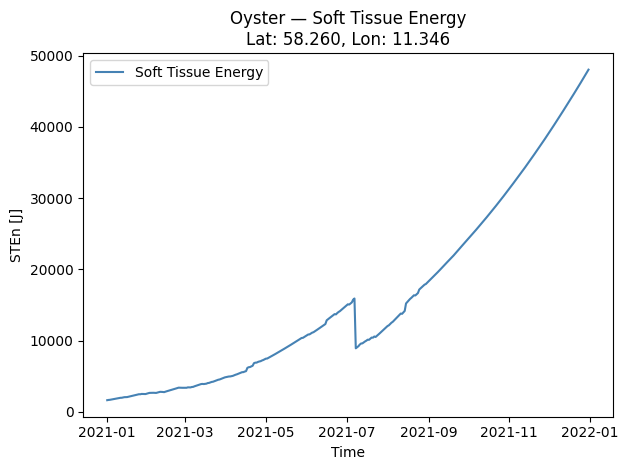

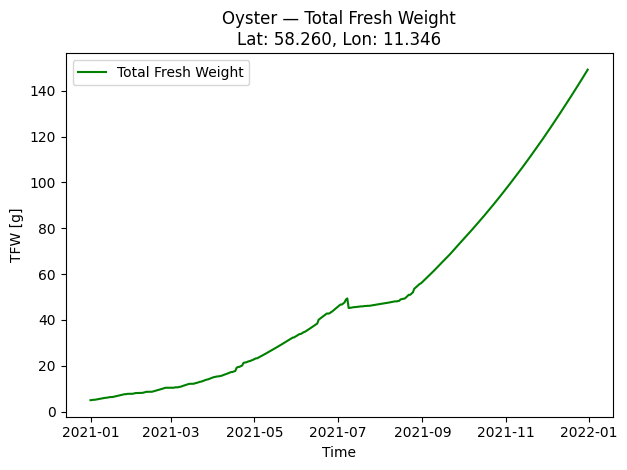

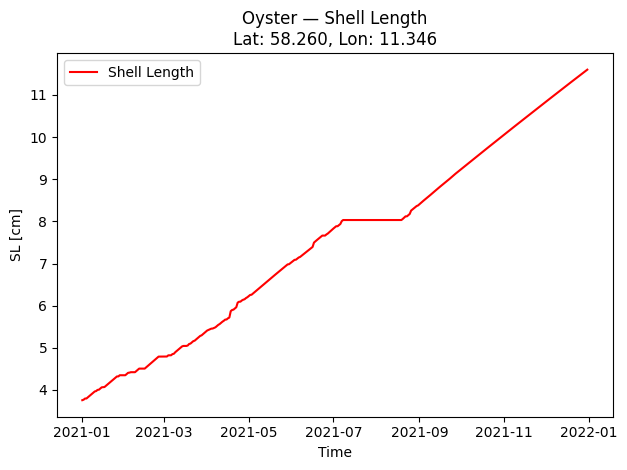

In [29]:



ds_out = ds_out.where(ds_out > -90)          # mask ShellSIM -99 sentinels
for var in ds_out.data_vars:
    ds_out[var] = ds_out[var].where(np.isfinite(ds_out[var].values))


plot_lat = 58.258995
plot_lon = 11.346692
print(f"Plotting time series for point: Lat={plot_lat}, Lon={plot_lon}")

try:
    single_point_data = ds_out.sel(
        latitude=plot_lat,
        longitude=plot_lon,
        method='nearest'
    ).load()

    actual_lat = float(single_point_data.latitude)
    actual_lon = float(single_point_data.longitude)
    print(f"Nearest pixel found at: Lat={actual_lat:.3f}, Lon={actual_lon:.3f}")

    all_nan = single_point_data.soft_tissue_energy.isnull().all()
    if all_nan:
        print("⚠️  Data at this point is all NaN (land or missing input data).")
        print("   Try a different coordinate — see the data coverage map cell.")

    # ── Plot 1: Soft Tissue Energy ──
    fig1, ax1 = plt.subplots()
    ax1.plot(single_point_data.time, single_point_data.soft_tissue_energy,
             label='Soft Tissue Energy', color='steelblue')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('STEn [J]')
    ax1.set_title(f'Oyster — Soft Tissue Energy\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax1.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Total Fresh Weight ──
    fig2, ax2 = plt.subplots()
    ax2.plot(single_point_data.time, single_point_data.TFW,
             label='Total Fresh Weight', color='green')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('TFW [g]')
    ax2.set_title(f'Oyster — Total Fresh Weight\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax2.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 3: Shell Length ──
    fig3, ax3 = plt.subplots()
    ax3.plot(single_point_data.time, single_point_data.SL,
             label='Shell Length', color='red')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('SL [cm]')
    ax3.set_title(f'Oyster — Shell Length\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax3.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error selecting data for plotting: {e}")
    print("Check that the output file exists and the coordinates fall within the domain.")

In [30]:
# # ============================================================
# # METHOD 2 — MEMORY-OPTIMISED BATCHED GRIDDED RUN For Large area 
# # ============================================================
# # Key fixes vs the previous version:
# #   1. Uses N_OUTPUTS (13) everywhere — NOT N_STATES (11).
# #      The wrapper returns 13 rows; telling apply_ufunc to expect
# #      11 causes a silent broadcast / shape mismatch error.
# #   2. Uses VARIABLE_NAMES (defined in the wrapper cell) as the
# #      authoritative 13-entry list so TFW and SL are written.
# #   3. Creates netCDF variables for ALL 13 outputs including
# #      TFW and SL before the tile loop begins.
# #   4. Writes TFW and SL into the output file exactly like the
# #      other state variables — no special-casing needed because
# #      they are just rows 11–12 of the returned array.
# # ============================================================

# time_horizon_len = ds_daily.time.size
# output_file_name = "gridded_oyster_output_ALL_STATES_batched.nc"

# # --- use the authoritative list from the wrapper cell ---
# # VARIABLE_NAMES has 13 entries: 11 states + TFW + SL
# # N_OUTPUTS = 13  (both defined in the wrapper cell above)

# # ============================================================
# # CHUNK INFO
# # ============================================================
# try:
#     lat_chunks = ds_daily.chunks['latitude']
#     lon_chunks = ds_daily.chunks['longitude']
# except Exception:
#     raise RuntimeError(
#         "ds_daily must be Dask-backed and chunked in latitude/longitude"
#     )

# lat_indices = np.cumsum([0] + list(lat_chunks))
# lon_indices = np.cumsum([0] + list(lon_chunks))

# total_lat = int(ds_daily.sizes["latitude"])
# total_lon = int(ds_daily.sizes["longitude"])

# # ============================================================
# # CREATE OUTPUT FILE ONCE — all 13 variables including TFW, SL
# # ============================================================
# if os.path.exists(output_file_name):
#     os.remove(output_file_name)

# nc = netCDF4.Dataset(output_file_name, "w", format="NETCDF4")

# nc.createDimension("time",      time_horizon_len)
# nc.createDimension("latitude",  total_lat)
# nc.createDimension("longitude", total_lon)

# # coordinate variables
# time_var = nc.createVariable("time", "f8", ("time",))
# time_seconds = (
#     pd.to_datetime(ds_daily.time.values)
#     .astype("datetime64[s]")
#     .astype(np.int64)
# )
# time_var[:]       = time_seconds
# time_var.units    = "seconds since 1970-01-01 00:00:00"
# time_var.calendar = "standard"

# lat_var        = nc.createVariable("latitude",  "f4", ("latitude",))
# lat_var[:]     = ds_daily.latitude.values.astype(np.float32)
# lat_var.units  = getattr(ds_daily["latitude"], "units", "degrees_north")

# lon_var        = nc.createVariable("longitude", "f4", ("longitude",))
# lon_var[:]     = ds_daily.longitude.values.astype(np.float32)
# lon_var.units  = getattr(ds_daily["longitude"], "units", "degrees_east")

# # one netCDF variable per output (13 total — states + TFW + SL)
# for name in VARIABLE_NAMES:
#     v = nc.createVariable(
#         name, "f4",
#         ("time", "latitude", "longitude"),
#         zlib=True, complevel=4,
#         fill_value=np.float32(np.nan),
#     )
#     # attach human-readable metadata
#     if name == "TFW":
#         v.long_name = "Total Fresh Weight"
#         v.units     = "g"
#     elif name == "SL":
#         v.long_name = "Shell Length"
#         v.units     = "cm"

# nc.sync()
# nc.close()

# print(f"Output file created: {output_file_name}")
# print(f"Variables to write ({len(VARIABLE_NAMES)}): {VARIABLE_NAMES}\n")
# print(f"Starting batched computation -> {output_file_name}")

# # ============================================================
# # PROCESS TILES AND WRITE
# # ============================================================
# for i in range(len(lat_chunks)):
#     lat_start = int(lat_indices[i])
#     lat_end   = int(lat_indices[i + 1])

#     for j in range(len(lon_chunks)):
#         lon_start = int(lon_indices[j])
#         lon_end   = int(lon_indices[j + 1])

#         print(
#             f"\nBatch Lat {i+1}/{len(lat_chunks)} ({lat_start}:{lat_end})  "
#             f"Lon {j+1}/{len(lon_chunks)} ({lon_start}:{lon_end})"
#         )

#         ds_subset = ds_daily.isel(
#             latitude=slice(lat_start, lat_end),
#             longitude=slice(lon_start, lon_end),
#         )

#         # apply_ufunc: vectorize over (lat, lon), keeping time as core dim.
#         # output_sizes MUST use N_OUTPUTS (13) — the wrapper returns 13 rows.
#         result_full_batch = xr.apply_ufunc(
#             run_fabm_at_point_full,
#             ds_subset["temperature"],
#             ds_subset["salinity"],
#             ds_subset["Chl"],
#             # ds_subset["POC"],
#             # ds_subset["POM"],
#             # ds_subset["TPM"],
#             input_core_dims=[["time"]] * 6,
#             output_core_dims=[["state", "time"]],
#             exclude_dims={"time"},
#             vectorize=True,
#             dask="parallelized",
#             output_dtypes=[float],
#             kwargs={"log_filename": RUN_LOG_FILENAME},
#             dask_gufunc_kwargs={
#                 "allow_rechunk": True,
#                 "output_sizes": {
#                     "state": N_OUTPUTS,      # <-- 13, not 11
#                     "time":  time_horizon_len,
#                 },
#             },
#         )

#         # Attach coordinate labels so to_dataset(dim='state') works correctly
#         result_full_batch = result_full_batch.assign_coords(
#             time=ds_subset.time,
#             state=VARIABLE_NAMES,            # <-- 13-entry list
#         )

#         result_dataset_batch = result_full_batch.to_dataset(dim="state")

#         with ProgressBar():
#             result_dataset_batch.load()

#         # ── Debug summary ──
#         print("\nChunk output summary:")
#         for var_name in VARIABLE_NAMES:
#             arr    = result_dataset_batch[var_name].values
#             total  = arr.size
#             nans   = np.isnan(arr).sum()
#             try:
#                 lo, hi = np.nanmin(arr), np.nanmax(arr)
#             except ValueError:
#                 lo = hi = np.nan
#             print(
#                 f"  {var_name:22s}  NaN%={100*nans/total:6.2f}  "
#                 f"min={lo:.4g}  max={hi:.4g}"
#             )

#         # ── Write tile into pre-created netCDF ──
#         nc = netCDF4.Dataset(output_file_name, "r+")
#         try:
#             for var_name in VARIABLE_NAMES:
#                 da = result_dataset_batch[var_name]

#                 # Identify dim names (apply_ufunc may return lat/lon in any order)
#                 dims     = list(da.dims)
#                 time_dim = next(d for d in dims if "time" in d.lower())
#                 lat_dim  = next(d for d in dims if "lat"  in d.lower())
#                 lon_dim  = next(d for d in dims if "lon"  in d.lower())

#                 arr = (
#                     da.transpose(time_dim, lat_dim, lon_dim)
#                     .values
#                     .astype(np.float32)
#                 )

#                 if arr.shape[0] != time_horizon_len:
#                     raise ValueError(
#                         f"Time-axis mismatch for '{var_name}': "
#                         f"got {arr.shape[0]}, expected {time_horizon_len}. "
#                         f"Full shape: {arr.shape}"
#                     )

#                 nc.variables[var_name][
#                     :, lat_start:lat_end, lon_start:lon_end
#                 ] = arr

#                 print(
#                     f"  Wrote {var_name:22s}  shape={arr.shape}  "
#                     f"NaNs={np.isnan(arr).sum()}"
#                 )

#             nc.sync()
#         finally:
#             nc.close()

#         del result_full_batch, result_dataset_batch, ds_subset
#         gc.collect()

# print(f"\n✅ Success: all batches processed and saved to {output_file_name}")

# How Dask scales the single-point model to a grid

**Core idea:** each pixel's oyster is independent (no exchange between grid cells), so the *unchanged* single-point function `run_fabm_at_point_full` can be applied to every `(lat, lon)` pixel in parallel. Dask schedules that work and reassembles the answers.

```
                         ds_daily  (temperature, salinity, Chl)
                         dims = (latitude, longitude, time)
                                        |
                    split into spatial CHUNKS (tiles); time kept whole
                    (time CANNOT be split — the model needs the full series)
                                        |
        +-----------------+-----------------+-----------------+
        |   chunk (0,0)   |   chunk (0,1)   |   chunk (1,0)   |  ...   <- lazy tasks
        +-----------------+-----------------+-----------------+
                |                 |                 |
           Worker 1          Worker 2          Worker 3      (separate PROCESSES,
        (own pyfabm)       (own pyfabm)      (own pyfabm)     1 thread each —
                |                 |                 |          pyfabm is NOT
   for each pixel in tile:  ...same...        ...same...      thread-safe)
   run_fabm_at_point_full(T_ts, S_ts, Chl_ts)
        -> (13 outputs, time) block per pixel
                |                 |                 |
        +-----------------+-----------------+-----------------+
                          scheduler reassembles
                                        |
                 result cube  dims = (state=13, latitude, longitude, time)
```

### Why processes, not threads
`Client(n_workers=4, threads_per_worker=1, processes=True)` — pyfabm holds C-level global state. Two models in the same process (threads) corrupt each other silently. Separate **processes** each get their own pyfabm instance → safe parallelism.

### Lazy until triggered
`apply_ufunc(..., dask='parallelized')` only builds the **recipe** (task graph). Nothing runs until `.compute()` / `.to_netcdf()`. At that moment workers crunch their chunks and the scheduler stitches the blocks into the final cube.

---

### Method 1 vs Method 2 — same engine, different memory profile

```
METHOD 1  (small / medium area)              METHOD 2  (large area, batched)
-------------------------------              -------------------------------
ONE graph for the WHOLE grid                 loop over lat/lon TILES:
   |                                            for each tile:
apply_ufunc over all pixels                       apply_ufunc on that tile
   |                                              .load()  (compute 1 tile)
.to_netcdf()  -> compute everything               write tile -> slot in .nc
   |                                              del tile + gc.collect()
result held in RAM, then saved               peak RAM = ONE tile (bounded)
```

| | Method 1 | Method 2 |
|---|---|---|
| Task graph | one for entire grid | one small graph per tile |
| Peak RAM | holds full result | one tile at a time |
| Output | built in memory, then saved | streamed tile-by-tile to disk |
| Best for | small/medium areas | large areas that don't fit in RAM |

Both produce the **same** `(state, lat, lon, time)` result — Method 2 just bounds memory so an arbitrarily large map is possible.


# Section 2
## Read and explore produced output

---
## Point Insight Section
The following cells provide a deep-dive analysis for a **single user-selected (lat, lon) point**.
Run the valid-point-finder cells above first to identify a coordinate with non-NaN model output,
then set `insight_lat` and `insight_lon` in Cell A before running this section.

These insights answer the practical question: *How well would an oyster farm perform at this exact location?*

## Point Insight Dashboard
A 6-panel summary figure giving an at-a-glance view of oyster growth at the selected point.
Each panel highlights a different aspect of performance: energy content, commercial weight,
shell length, daily growth rate, cumulative weight gain, and seasonal patterns.
This is the first plot a stakeholder should see when evaluating a candidate farm site.

In [31]:
HARVEST_SL_CM = 8.0  # cm — standard harvest shell length
MARKET_WEIGHT_G = 60.0  # grams — typical marketable size threshold

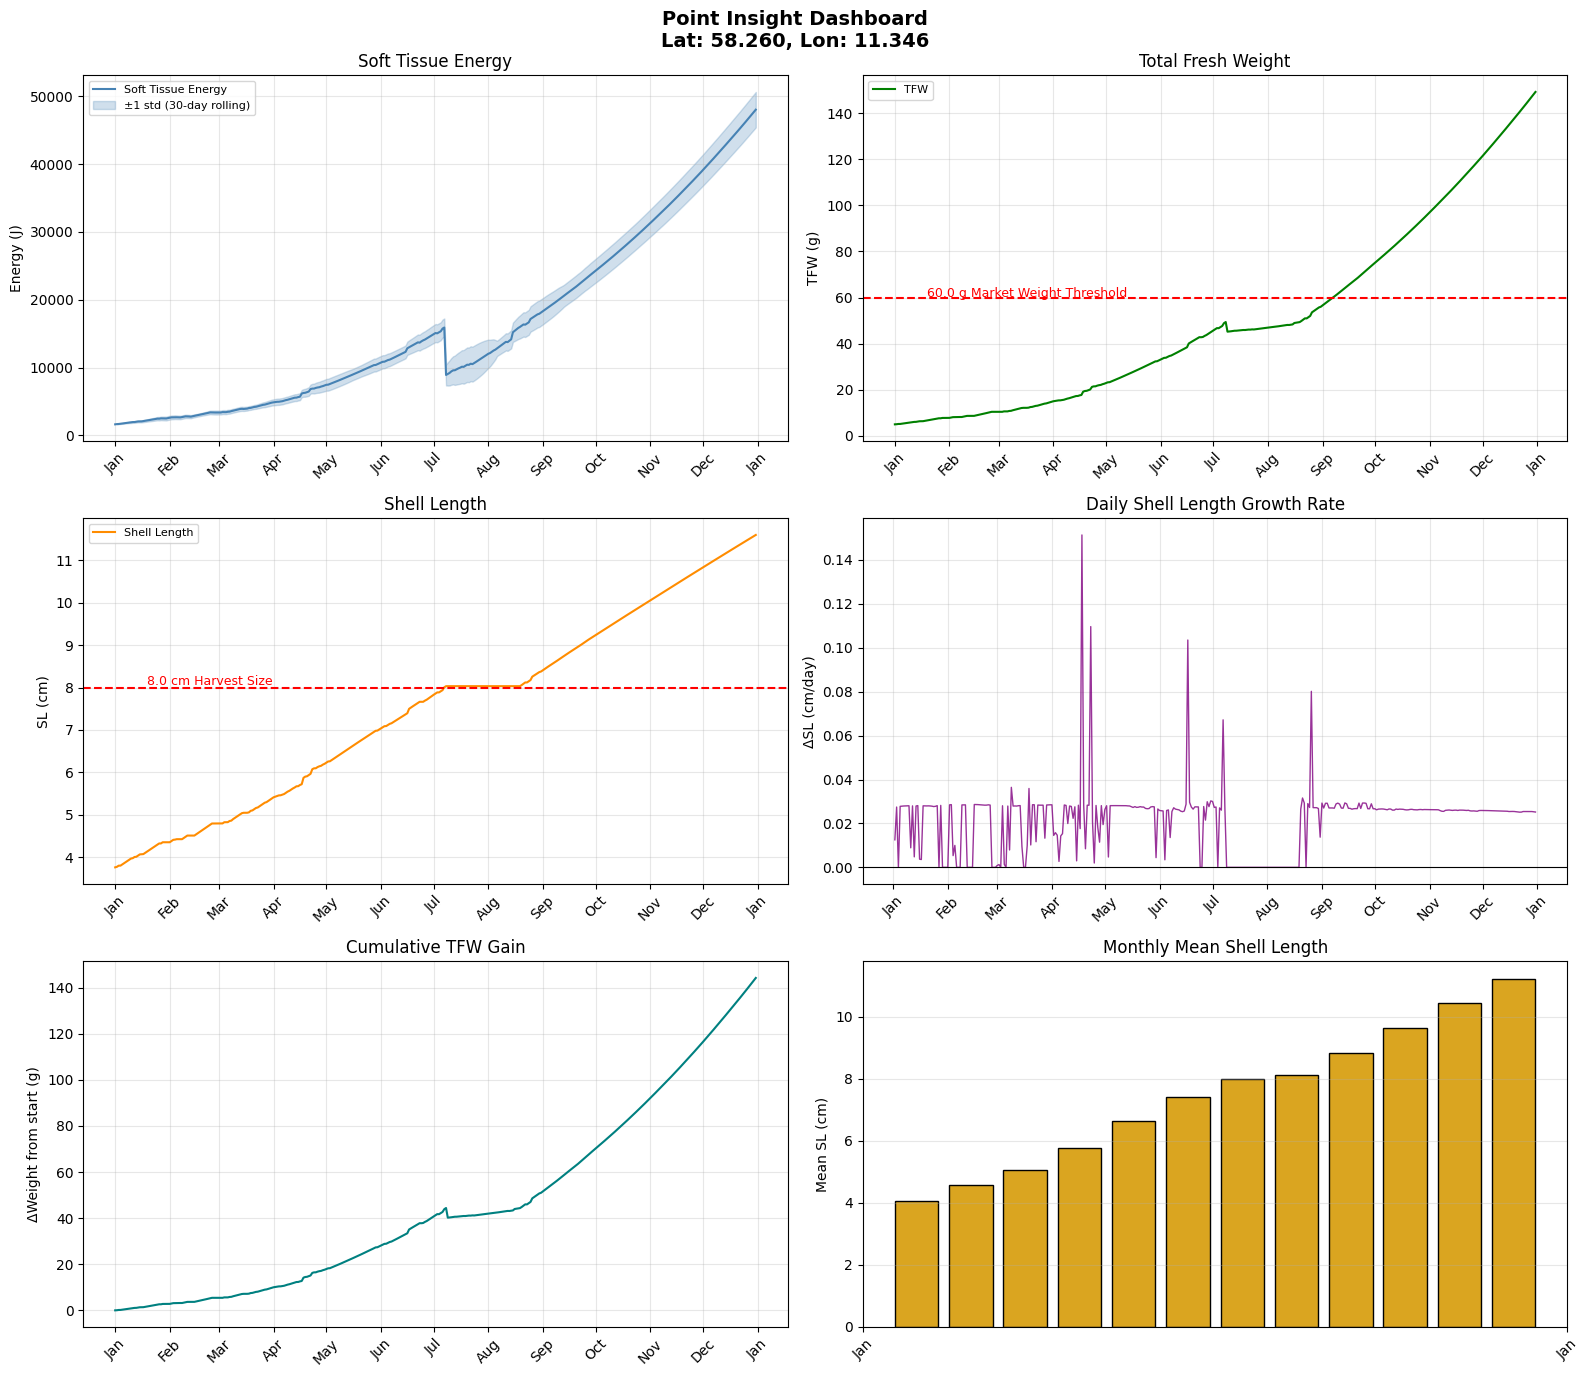

Saved: point_insight_dashboard.png


In [32]:
# ============================================================
# CELL A: POINT INSIGHT DASHBOARD — 6-PANEL FIGURE
# ============================================================
# Extracts the full time series for a single (lat, lon) point
# and plots 6 panels covering key growth indicators.
# Set insight_lat and insight_lon to the valid point found above.

# # --- User inputs: set these to your point of interest ---
# insight_lat = new_plot_lat  # replace with a valid lat if new_plot_lat is undefined
# insight_lon = new_plot_lon  # replace with a valid lon if new_plot_lon is undefined



# --- User inputs: set these to your point of interest ---
insight_lat = 58.258995  # replace with a valid lat if new_plot_lat is undefined
insight_lon = 11.346692 # replace with a valid lon if new_plot_lon is undefined

# Load just this pixel's data into memory
pt = result_dataset.sel(
    latitude=insight_lat, longitude=insight_lon, method='nearest'
).load()

# Extract 1-D numpy arrays for convenience
times     = pt.time.values
ste       = pt['soft_tissue_energy'].values.astype(float)
tfw       = pt['TFW'].values.astype(float)
sl        = pt['SL'].values.astype(float)

# Compute derived series
sl_growth_rate   = np.concatenate([[np.nan], np.diff(sl)])   # daily SL change (cm/day)
tfw_cumulative   = tfw - np.nanmean(tfw[:1])                 # cumulative TFW gain from start

# Monthly mean SL for bar chart (Panel 6)
times_pd  = pd.DatetimeIndex(times)
df_monthly = pd.DataFrame({'SL': sl, 'month': times_pd.month})
monthly_sl = df_monthly.groupby('month')['SL'].mean()

# Rolling 30-day std for STEn shaded band (Panel 1)
ste_series = pd.Series(ste, index=times_pd)
ste_roll_std = ste_series.rolling(30, min_periods=1).std().values

# ---- Build 3x2 figure ----
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()

# Panel 1: Soft Tissue Energy with ±1 std band
ax = axes[0]
ax.plot(times, ste, color='steelblue', linewidth=1.5, label='Soft Tissue Energy')
ax.fill_between(times, ste - ste_roll_std, ste + ste_roll_std,
                alpha=0.25, color='steelblue', label='±1 std (30-day rolling)')
ax.set_title('Soft Tissue Energy')
ax.set_ylabel('Energy (J)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Total Fresh Weight with market threshold line

ax = axes[1]
ax.plot(times, tfw, color='green', linewidth=1.5, label='TFW')
ax.axhline(MARKET_WEIGHT_G, color='red', linestyle='--', linewidth=1.5)
ax.text(times[len(times)//20], MARKET_WEIGHT_G + 0.05,
        f'{MARKET_WEIGHT_G} g Market Weight Threshold', color='red', fontsize=9)
ax.set_title('Total Fresh Weight')
ax.set_ylabel('TFW (g)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Shell Length with harvest size line

ax = axes[2]
ax.plot(times, sl, color='darkorange', linewidth=1.5, label='Shell Length')
ax.axhline(HARVEST_SL_CM, color='red', linestyle='--', linewidth=1.5)
ax.text(times[len(times)//20], HARVEST_SL_CM + 0.05,
        f'{HARVEST_SL_CM} cm Harvest Size', color='red', fontsize=9)
ax.set_title('Shell Length')
ax.set_ylabel('SL (cm)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Daily SL growth rate
ax = axes[3]
ax.plot(times, sl_growth_rate, color='purple', linewidth=1.0, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_title('Daily Shell Length Growth Rate')
ax.set_ylabel('ΔSL (cm/day)')
ax.grid(True, alpha=0.3)

# Panel 5: Cumulative TFW gain
ax = axes[4]
ax.plot(times, tfw_cumulative, color='teal', linewidth=1.5)
ax.set_title('Cumulative TFW Gain')
ax.set_ylabel('ΔWeight from start (g)')
ax.grid(True, alpha=0.3)

# Panel 6: Monthly bar chart of mean SL
ax = axes[5]
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(monthly_sl.index, monthly_sl.values, color='goldenrod', edgecolor='black')
ax.set_xticks(monthly_sl.index)
ax.set_xticklabels([month_names[m-1] for m in monthly_sl.index], rotation=45)
ax.set_title('Monthly Mean Shell Length')
ax.set_ylabel('Mean SL (cm)')
ax.grid(True, alpha=0.3, axis='y')

# ── Readable monthly x-axis ticks for all panels ──────────────────
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    f'Point Insight Dashboard\n'
    f'Lat: {pt.latitude.item():.3f}, Lon: {pt.longitude.item():.3f}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
# plt.savefig('point_insight_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: point_insight_dashboard.png')

## Point Statistical Summary
A concise table summarising key statistics for the three most important output variables
(Soft Tissue Energy, Total Fresh Weight, Shell Length) at the selected point.
This lets a farm manager quickly compare candidate sites without reading plots.

In [33]:
# ============================================================
# CELL B: POINT STATISTICAL SUMMARY TABLE
# ============================================================
# Computes summary statistics for soft_tissue_energy, TFW, SL
# at the selected pixel and prints them as a pandas DataFrame.
# Uses skipna=True / np.nanXxx to handle any residual NaNs.

# Map variable names to arrays already extracted in Cell A
stat_vars = {
    'soft_tissue_energy': ste,
    'TFW':                tfw,
    'SL':                 sl,
}

rows = {}
for vname, arr in stat_vars.items():
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        rows[vname] = {'min': np.nan, 'max': np.nan, 'mean': np.nan,
                       'std': np.nan, 'final_value': np.nan,
                       'peak_date': 'N/A', 'days_above_median': 0}
        continue
    median_val  = np.nanmedian(arr)
    peak_idx    = np.nanargmax(arr)
    rows[vname] = {
        'min':              round(float(np.nanmin(arr)), 4),
        'max':              round(float(np.nanmax(arr)), 4),
        'mean':             round(float(np.nanmean(arr)), 4),
        'std':              round(float(np.nanstd(arr)), 4),
        'final_value':      round(float(arr[-1]), 4),
        'peak_date':        str(pd.Timestamp(times[peak_idx]).date()),
        'days_above_median': int(np.sum(arr > median_val)),
    }

df_stats = pd.DataFrame(rows).T
print('=== Point Statistical Summary ===')
print(f'Location: Lat {pt.latitude.item():.3f}, Lon {pt.longitude.item():.3f}')
print()
print(df_stats.to_string())


=== Point Statistical Summary ===
Location: Lat 58.260, Lon 11.346

                          min         max        mean         std final_value   peak_date days_above_median
soft_tissue_energy  1615.5028  48052.1231  15936.7845  12931.7396  48052.1231  2021-12-31               182
TFW                       5.0    149.1663     50.5197     39.8557    149.1663  2021-12-31               182
SL                     3.7567     11.6001      7.4911      2.2336     11.6001  2021-12-31               182


## Point Harvest Readiness
Answers the central commercial question: *When will the oysters at this site be ready to harvest?*
Reports the first date each size threshold is crossed and the fraction of the model period
when both conditions are met simultaneously.

In [34]:
# ============================================================
# CELL C: POINT HARVEST READINESS
# ============================================================
# Identifies threshold crossing dates and the fraction of the
# modelled period when both SL>=6 cm AND TFW>=5 g are satisfied.



# Convert time array to pandas DatetimeIndex for easy formatting
times_pd = pd.DatetimeIndex(times)

# First date SL reaches harvest size
sl_ready_mask = sl >= HARVEST_SL_CM
if sl_ready_mask.any():
    first_sl_date  = times_pd[sl_ready_mask][0]
    days_to_sl     = (first_sl_date - times_pd[0]).days
else:
    first_sl_date  = None
    days_to_sl     = None

# First date TFW reaches market weight
tfw_ready_mask = tfw >= MARKET_WEIGHT_G
if tfw_ready_mask.any():
    first_tfw_date = times_pd[tfw_ready_mask][0]
    days_to_tfw    = (first_tfw_date - times_pd[0]).days
else:
    first_tfw_date = None
    days_to_tfw    = None

# Fraction of period where BOTH thresholds are simultaneously met
both_ready_mask = sl_ready_mask & tfw_ready_mask
pct_both_ready  = 100.0 * np.sum(both_ready_mask) / len(sl)

print('=== Point Harvest Readiness ===')
print(f'Location : Lat {pt.latitude.item():.3f}, Lon {pt.longitude.item():.3f}')
print(f'Period   : {str(times_pd[0].date())} to {str(times_pd[-1].date())}')
print()
if first_sl_date:
    print(f'First date SL >= {HARVEST_SL_CM} cm  : {first_sl_date.date()} ({days_to_sl} days from start)')
else:
    print(f'SL NEVER reached {HARVEST_SL_CM} cm within the model period')
if first_tfw_date:
    print(f'First date TFW >= {MARKET_WEIGHT_G} g  : {first_tfw_date.date()} ({days_to_tfw} days from start)')
else:
    print(f'TFW NEVER reached {MARKET_WEIGHT_G} g within the model period')
print()
print(f'% of period when BOTH thresholds met : {pct_both_ready:.1f}%')


=== Point Harvest Readiness ===
Location : Lat 58.260, Lon 11.346
Period   : 2021-01-01 to 2021-12-31

First date SL >= 8.0 cm  : 2021-07-07 (187 days from start)
First date TFW >= 60.0 g  : 2021-09-07 (249 days from start)

% of period when BOTH thresholds met : 31.8%


## Point Seasonal Breakdown
Groups the time series by calendar month to show seasonal growth patterns.
Understanding which months have the best growth conditions helps optimise
seeding and harvest schedules.

=== Monthly Mean SL (cm) and TFW (g) ===
            SL         TFW
Jan   4.073994    6.434118
Feb   4.560504    9.015585
Mar   5.048056   12.234534
Apr   5.766735   18.311639
May   6.621203   27.684313
Jun   7.412656   38.876000
Jul   8.002564   46.340836
Aug   8.104815   49.879515
Sep   8.810609   65.307346
Oct   9.635310   85.461725
Nov  10.433308  108.553498
Dec  11.218887  135.055822


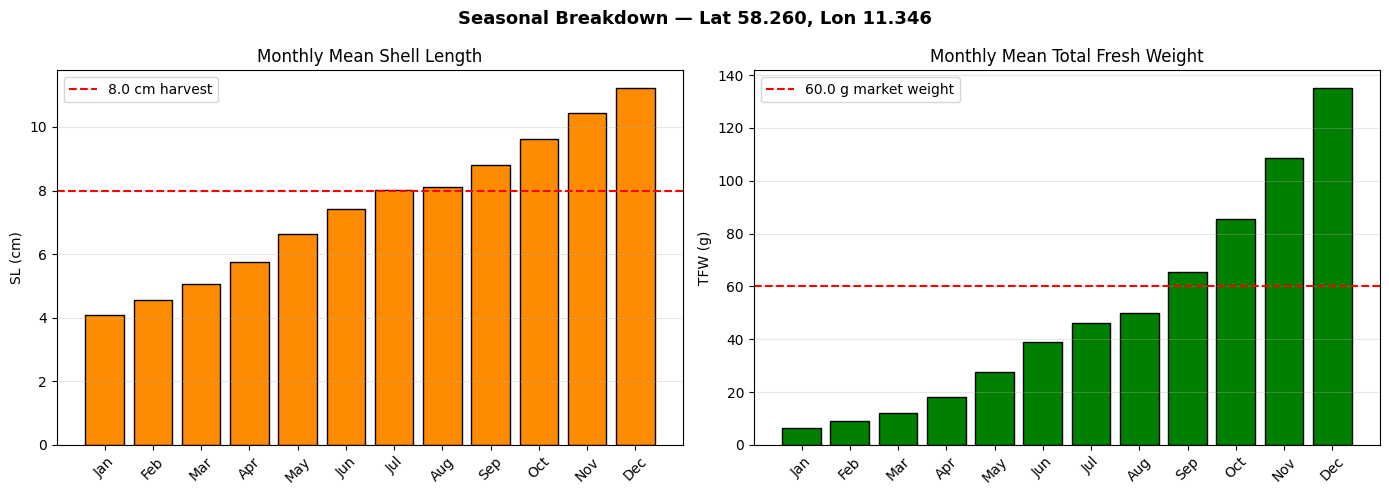

Saved: point_seasonal_breakdown.png


In [35]:
# ============================================================
# CELL D: POINT SEASONAL BREAKDOWN
# ============================================================
# Groups SL and TFW by calendar month, computes monthly means,
# prints a summary table, and plots grouped bar charts.

times_pd = pd.DatetimeIndex(times)
df_season = pd.DataFrame({
    'month': times_pd.month,
    'SL':    sl,
    'TFW':   tfw,
})

monthly_means = df_season.groupby('month')[['SL', 'TFW']].mean()

# Print summary table
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_means.index = [month_names[m-1] for m in monthly_means.index]
print('=== Monthly Mean SL (cm) and TFW (g) ===')
print(monthly_means.to_string())

# Bar chart for each variable side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_means.index, monthly_means['SL'],
            color='darkorange', edgecolor='black')
axes[0].axhline(HARVEST_SL_CM, color='red', linestyle='--', label=f'{HARVEST_SL_CM} cm harvest')
axes[0].set_title('Monthly Mean Shell Length')
axes[0].set_ylabel('SL (cm)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(monthly_means.index, monthly_means['TFW'],
            color='green', edgecolor='black')
axes[1].axhline(MARKET_WEIGHT_G, color='red', linestyle='--', label=f'{MARKET_WEIGHT_G} g market weight')
axes[1].set_title('Monthly Mean Total Fresh Weight')
axes[1].set_ylabel('TFW (g)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Seasonal Breakdown — Lat {pt.latitude.item():.3f}, Lon {pt.longitude.item():.3f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
# plt.savefig('point_seasonal_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: point_seasonal_breakdown.png')


---
## Bounding Box (BBox) Area Insights Section
The following cells analyse model output across a **user-defined geographic bounding box**
and date range. This simulates the workflow where a user draws a rectangle on a map,
picks a season, and asks: *Which parts of this region are best for oyster farming?*



In [36]:
ds_bbox = result_dataset
# print(ds_bbox)

<xarray.Dataset> Size: 45MB
Dimensions:             (latitude: 29, longitude: 53, time: 365)
Coordinates:
  * latitude            (latitude) float64 232B 58.33 58.33 ... 58.25 58.24
  * longitude           (longitude) float64 424B 11.34 11.34 ... 11.49 11.49
  * time                (time) datetime64[ns] 3kB 2021-01-01 ... 2021-12-31
Data variables:
    soft_tissue_energy  (latitude, longitude, time) float64 4MB dask.array<chunksize=(29, 53, 365), meta=np.ndarray>
    shell_energy        (latitude, longitude, time) float64 4MB dask.array<chunksize=(29, 53, 365), meta=np.ndarray>
    aging               (latitude, longitude, time) float64 4MB dask.array<chunksize=(29, 53, 365), meta=np.ndarray>
    C1                  (latitude, longitude, time) float64 4MB dask.array<chunksize=(29, 53, 365), meta=np.ndarray>
    C2                  (latitude, longitude, time) float64 4MB dask.array<chunksize=(29, 53, 365), meta=np.ndarray>
    C3                  (latitude, longitude, time) float64 4MB 

## BBox: Spatial Summary Maps
Three-panel map showing the **time-averaged** Shell Length, Total Fresh Weight, and
Soft Tissue Energy across the bounding box. These maps immediately reveal spatial
gradients — e.g. higher growth near coastal upwelling zones or warmer southern waters.

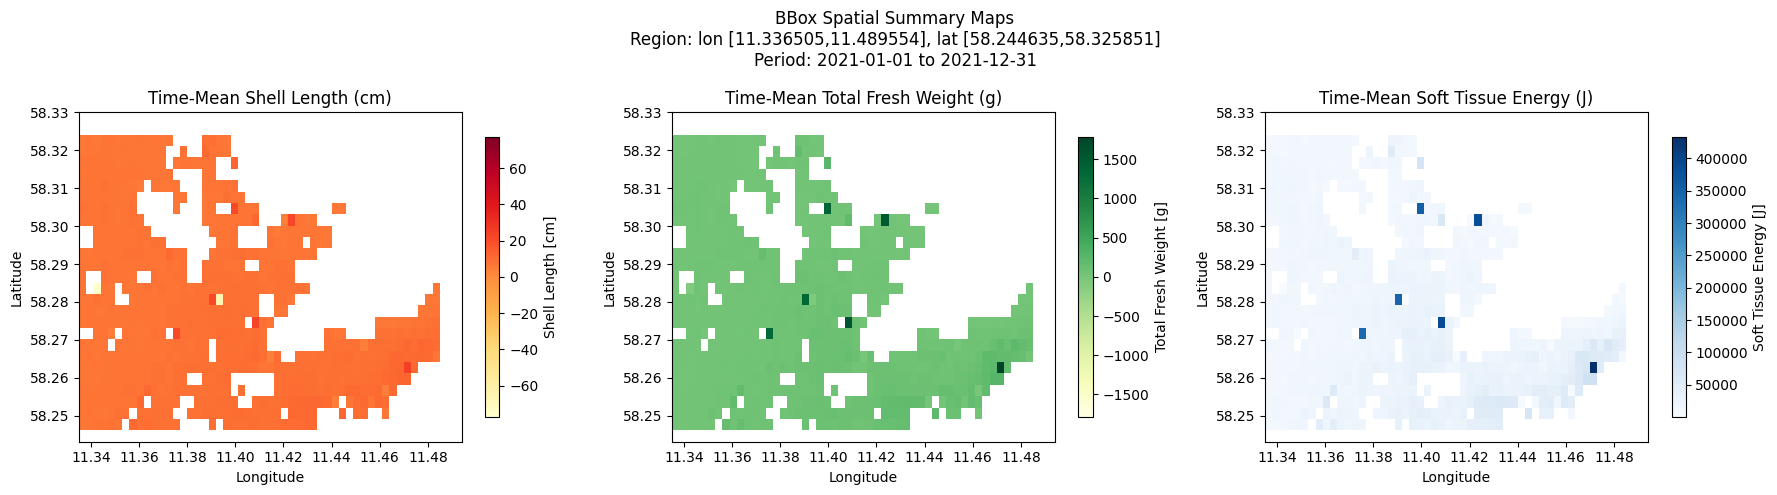

Saved: bbox_spatial_summary.png


In [37]:
# ============================================================
# CELL F: BBOX SPATIAL SUMMARY MAPS (TIME MEAN)
# ============================================================
# Collapses the time dimension by averaging, then plots each
# variable as a 2-D map over the bounding box.
# xarray's .plot() attaches the colorbar automatically.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_specs = [
    ('SL',                'Shell Length (cm)',     'YlOrRd'),
    ('TFW',               'Total Fresh Weight (g)','YlGn'),
    ('soft_tissue_energy','Soft Tissue Energy (J)','Blues'),
]

for ax, (vname, title, cmap) in zip(axes, plot_specs):
    # skipna=True ignores land / missing-data NaNs in the mean
    da_mean = ds_bbox[vname].mean(dim='time', skipna=True)
    da_mean.plot(ax=ax, cmap=cmap, add_colorbar=True,
                cbar_kwargs={'shrink': 0.85})
    ax.set_title(f'Time-Mean {title}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle(
    f'BBox Spatial Summary Maps\n'
    f'Region: lon [{bbox[0]},{bbox[2]}], lat [{bbox[1]},{bbox[3]}]\n'
    f'Period: {start_date} to {end_date}',
    fontsize=12
)
plt.tight_layout()
# plt.savefig('bbox_spatial_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bbox_spatial_summary.png')


## BBox: Area-Averaged Time Series
Shows how the **spatial mean** of SL, TFW, and Soft Tissue Energy evolves over time
across the entire bounding box, with a shaded band showing pixel-to-pixel variability (±1 std).
This answers: *On average, when does the region reach peak growth?*

In [38]:
# # ============================================================
# # CELL G: BBOX AREA-AVERAGED TIME SERIES WITH STD BAND
# # ============================================================
# # Takes the spatial mean across all (lat, lon) pixels for each
# # time step (skipna=True to handle land NaNs), plus the spatial
# # std as a measure of inter-pixel variability / spatial spread.

# fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ts_specs = [
#     ('SL',                'Shell Length (cm)',     'darkorange'),
#     ('TFW',               'Total Fresh Weight (g)','green'),
#     ('soft_tissue_energy','Soft Tissue Energy (J)','steelblue'),
# ]

# bbox_times = pd.DatetimeIndex(ds_bbox.time.values)

# for ax, (vname, ylabel, color) in zip(axes, ts_specs):
#     # Area mean and std across lat and lon at each time step
#     area_mean = ds_bbox[vname].mean(dim=['latitude','longitude'], skipna=True).values
#     area_std  = ds_bbox[vname].std( dim=['latitude','longitude'], skipna=True).values

#     ax.plot(bbox_times, area_mean, color=color, linewidth=1.8, label='Area mean')
#     ax.fill_between(bbox_times,
#                     area_mean - area_std,
#                     area_mean + area_std,
#                     alpha=0.25, color=color, label='±1 std (pixel spread)')
#     ax.set_ylabel(ylabel)
#     ax.legend(fontsize=9)
#     ax.grid(True, alpha=0.3)

# axes[0].set_title(
#     f'BBox Area-Averaged Time Series ({start_date} – {end_date})',
#     fontsize=12, fontweight='bold'
# )
# axes[-1].set_xlabel('Date')
# plt.tight_layout()
# # plt.savefig('bbox_area_mean_timeseries.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved: bbox_area_mean_timeseries.png')


## BBox: Statistical Summary Table
Aggregates all pixels and all time steps within the bounding box into a single summary table,
including min, max, mean, std, and quartiles. Useful for comparing multiple regions side-by-side.

In [39]:
# ============================================================
# CELL H: BBOX STATISTICAL SUMMARY TABLE
# ============================================================
# Flattens each variable across ALL (lat, lon, time) dimensions
# and computes descriptive statistics. NaNs are excluded.

rows = {}
for vname in ['SL', 'TFW', 'soft_tissue_energy']:
    flat = ds_bbox[vname].values.ravel()
    flat = flat[~np.isnan(flat)]
    if len(flat) == 0:
        rows[vname] = {k: np.nan for k in ['min','max','mean','std','p25','p75']}
        continue
    rows[vname] = {
        'min':  round(float(np.min(flat)), 4),
        'max':  round(float(np.max(flat)), 4),
        'mean': round(float(np.mean(flat)), 4),
        'std':  round(float(np.std(flat)), 4),
        'p25':  round(float(np.percentile(flat, 25)), 4),
        'p75':  round(float(np.percentile(flat, 75)), 4),
    }

df_bbox_stats = pd.DataFrame(rows).T
print('=== BBox Statistical Summary (all pixels, all time steps) ===')
print(f'Region : lon [{bbox[0]},{bbox[2]}], lat [{bbox[1]},{bbox[3]}]')
print(f'Period : {start_date} to {end_date}')
print()
print(df_bbox_stats.to_string())


=== BBox Statistical Summary (all pixels, all time steps) ===
Region : lon [11.336505,11.489554], lat [58.244635,58.325851]
Period : 2021-01-01 to 2021-12-31

                     min          max        mean         std        p25         p75
SL                 -99.0      30.2699      8.0174      5.7429     5.7807      9.9861
TFW                -99.0    2647.2793     80.8486    174.1675    18.3394     94.4092
soft_tissue_energy   0.0  855305.9175  24826.8851  45402.4918  5904.7463  29942.2014


## BBox: Growth Hotspot Map
Maps the **final Shell Length** at every pixel in the bounding box.
Pixels in the top 10% are highlighted with a red star overlay.
This directly shows *where* within the region oysters grow largest — the prime farming locations.

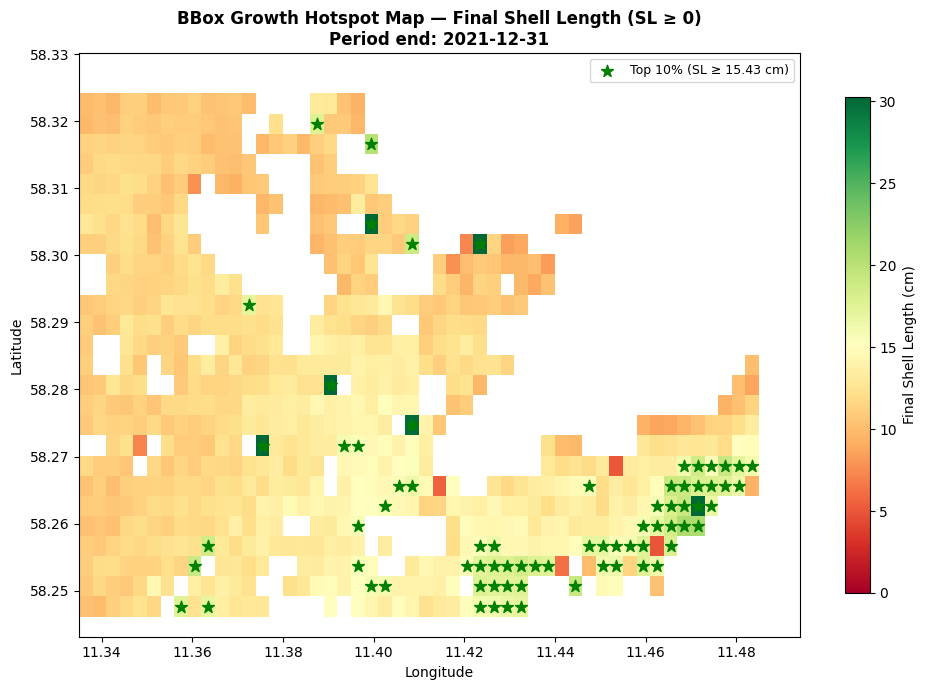

In [40]:
# ============================================================
# CELL I: BBOX GROWTH HOTSPOT MAP (SL >= 0 ONLY)
# ============================================================

# Final Shell Length
sl_final = ds_bbox['SL'].isel(time=-1).values.copy()

lats_bbox = ds_bbox.latitude.values
lons_bbox = ds_bbox.longitude.values

# Ignore negative shell lengths
sl_plot = np.where(sl_final >= 0, sl_final, np.nan)

# Top 10% threshold using only SL >= 0
sl_valid = sl_plot[~np.isnan(sl_plot)]
top10_thresh = np.percentile(sl_valid, 90) if len(sl_valid) else np.nan

fig, ax = plt.subplots(figsize=(10, 7))

# Create lon/lat grids
lon_grid, lat_grid = np.meshgrid(lons_bbox, lats_bbox)

# Plot with colourbar starting at 0
pcm = ax.pcolormesh(
    lon_grid,
    lat_grid,
    sl_plot,
    cmap="RdYlGn",   

    shading="auto",
    vmin=0,
    vmax=np.nanmax(sl_plot)
    # vmin=np.nanpercentile(sl_plot, 5),
    # vmax=np.nanpercentile(sl_plot, 95)
)

plt.colorbar(
    pcm,
    ax=ax,
    label="Final Shell Length (cm)",
    shrink=0.85
)

# Overlay top 10% hotspots
if not np.isnan(top10_thresh):
    hot_mask = sl_plot >= top10_thresh
    hot_lat_idx, hot_lon_idx = np.where(hot_mask)

    ax.scatter(
        lons_bbox[hot_lon_idx],
        lats_bbox[hot_lat_idx],
        marker="*",
        color="green",
        s=80,
        zorder=5,
        label=f"Top 10% (SL ≥ {top10_thresh:.2f} cm)"
    )
    ax.legend(fontsize=9)

ax.set_title(
    "BBox Growth Hotspot Map — Final Shell Length (SL ≥ 0)\n"
    f"Period end: {pd.Timestamp(ds_bbox.time.values[-1]).date()}",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

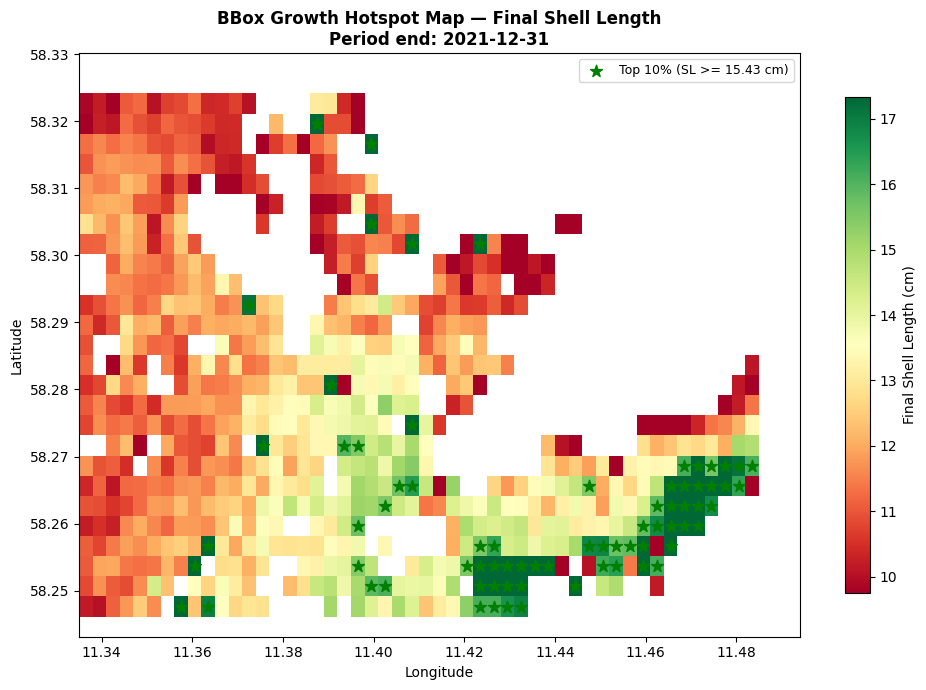

Saved: bbox_hotspot_map.png


In [41]:
# ============================================================
# CELL I: BBOX GROWTH HOTSPOT MAP
# ============================================================
# Extracts SL at the last time step, plots a spatial map,
# and overlays red stars on pixels in the top 10%.

# Final SL = value at the last time step for each pixel
sl_final = ds_bbox['SL'].isel(time=-1).values  # shape (lat, lon)
lats_bbox = ds_bbox.latitude.values
lons_bbox = ds_bbox.longitude.values

# Threshold for top 10% (ignoring NaNs)
sl_flat    = sl_final[~np.isnan(sl_final)]
top10_thresh = np.percentile(sl_flat, 90) if len(sl_flat) > 0 else np.nan

fig, ax = plt.subplots(figsize=(10, 7))

# Plot the final SL map
lon_grid, lat_grid = np.meshgrid(lons_bbox, lats_bbox)
pcm = ax.pcolormesh(lon_grid, lat_grid, sl_final,
                    cmap='RdYlGn', shading='auto',
                       vmin=np.nanpercentile(sl_final, 5),
                        vmax=np.nanpercentile(sl_final, 95)
                        )
plt.colorbar(pcm, ax=ax, label='Final Shell Length (cm)', shrink=0.85)

# Overlay red stars on top-10% pixels
if not np.isnan(top10_thresh):
    hot_mask = sl_final >= top10_thresh
    hot_lats_idx, hot_lons_idx = np.where(hot_mask)
    ax.scatter(
        lons_bbox[hot_lons_idx], lats_bbox[hot_lats_idx],
        marker='*', color='green', s=80, zorder=5,
        label=f'Top 10% (SL >= {top10_thresh:.2f} cm)'
    )
    ax.legend(fontsize=9)

ax.set_title(
    f'BBox Growth Hotspot Map — Final Shell Length\n'
    f'Period end: {str(pd.Timestamp(ds_bbox.time.values[-1]).date())}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
# plt.savefig('bbox_hotspot_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bbox_hotspot_map.png')

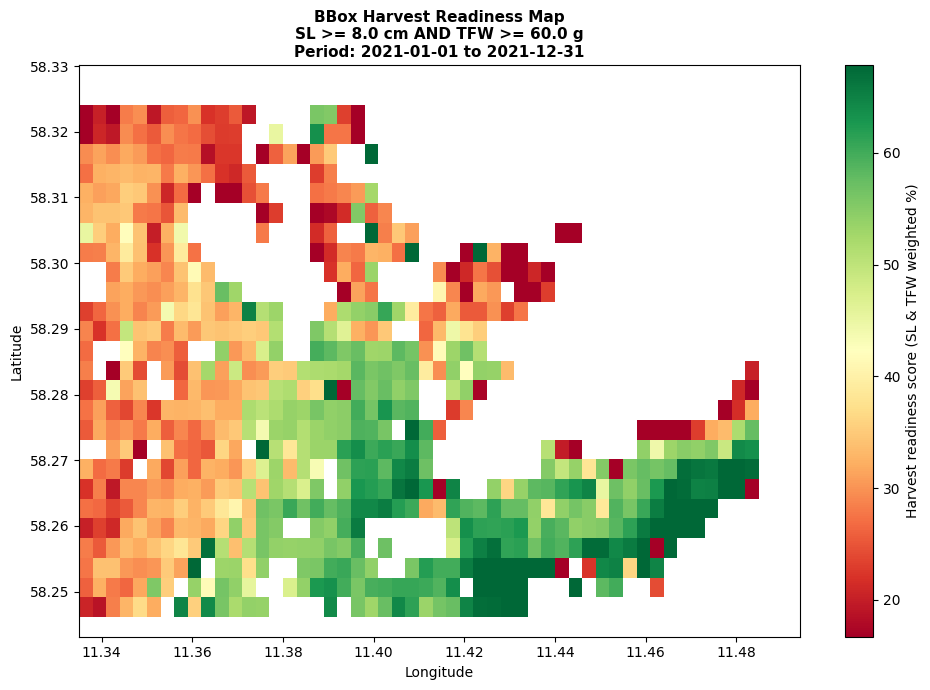

Saved: bbox_harvest_map.png
% of pixels that EVER reach harvest thresholds : 98.2%
Mean harvest-ready fraction across all pixels  : 41.8%


In [42]:
# ============================================================
# CELL J: BBOX HARVEST READINESS MAP
# ============================================================


# xarray loads as (time, latitude, longitude) — axis 0 is time
# Arrays are (lat, lon, time)
sl_arr  = ds_bbox['SL'].values
tfw_arr = ds_bbox['TFW'].values

both_ready = (
    (sl_arr >= HARVEST_SL_CM) &
    (tfw_arr >= MARKET_WEIGHT_G)
)

# Number of timesteps
n_times = sl_arr.shape[2]

# Fraction of time each pixel is harvest-ready
harvest_frac = np.nansum(both_ready, axis=2) / n_times

# Remove pixels with no data for the whole period
harvest_frac[np.all(np.isnan(sl_arr), axis=2)] = np.nan

# Overall area percentage
valid_pixels   = harvest_frac[~np.isnan(harvest_frac)]
pct_area_ready = 100.0 * np.mean(valid_pixels > 0) if len(valid_pixels) > 0 else 0.0
mean_frac      = 100.0 * np.nanmean(valid_pixels)  if len(valid_pixels) > 0 else 0.0

# Plot — meshgrid matches (lat, lon) order of harvest_frac
fig, ax = plt.subplots(figsize=(10, 7))
lon_grid, lat_grid = np.meshgrid(ds_bbox.longitude.values, ds_bbox.latitude.values)



pcm = ax.pcolormesh(lon_grid, lat_grid, harvest_frac * 100,
                    cmap='RdYlGn', 
                    # vmin=0, 
                    # vmax=100, 

                    vmin = np.nanpercentile(harvest_frac * 100, 5),
                    vmax = np.nanpercentile(harvest_frac * 100, 95),
                    shading='auto')

plt.colorbar(pcm, ax=ax, label='Harvest readiness score (SL & TFW weighted %)')


ax.set_title(
    f'BBox Harvest Readiness Map\n'
    f'SL >= {HARVEST_SL_CM} cm AND TFW >= {MARKET_WEIGHT_G} g\n'
    f'Period: {start_date} to {end_date}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
# plt.savefig('bbox_harvest_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bbox_harvest_map.png')
print(f'% of pixels that EVER reach harvest thresholds : {pct_area_ready:.1f}%')
print(f'Mean harvest-ready fraction across all pixels  : {mean_frac:.1f}%')


In [43]:
# ============================================================
# CELL JB: BBOX HARVEST READINESS MAP on top of leaflet map
# ============================================================
import branca
from matplotlib import cm
import folium

vals_pct = harvest_frac * 100.0
mask_nan = np.isnan(vals_pct)
normed = np.zeros_like(vals_pct, dtype=float)
valid_mask = ~mask_nan

# ✅ Percentile stretch BEFORE colormap is applied
if np.any(valid_mask):
    vmin = np.nanpercentile(vals_pct[valid_mask], 5)
    vmax = np.nanpercentile(vals_pct[valid_mask], 95)
    normed[valid_mask] = np.clip(
        (vals_pct[valid_mask] - vmin) / (vmax - vmin),
        0.0, 1.0
    )

# Apply colormap to stretched normed array
cmap = cm.get_cmap('RdYlGn')
rgba_f = cmap(normed)
rgba_f[mask_nan, :] = np.array([0.0, 0.0, 0.0, 0.0])
rgba_img = (rgba_f * 255).astype(np.uint8)

lats = ds_bbox.latitude.values
if lats[0] < lats[-1]:
    rgba_img = np.flipud(rgba_img)

lat_min, lat_max = float(np.min(lats)), float(np.max(lats))
lon_min, lon_max = float(np.min(ds_bbox.longitude.values)), float(np.max(ds_bbox.longitude.values))
bounds = [[lat_min, lon_min], [lat_max, lon_max]]

center_lat = float(np.nanmean([lat_min, lat_max]))
center_lon = float(np.nanmean([lon_min, lon_max]))

m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles='CartoDB positron')

overlay = folium.raster_layers.ImageOverlay(
    image=rgba_img,
    bounds=bounds,
    name='Harvest Readiness (%)',
    opacity=0.75,
    interactive=True,
    cross_origin=False,
    zindex=1,
)
overlay.add_to(m)

summary_html = (
    f"<b>BBox Harvest Readiness</b><br>"
    f"% pixels ever ready : {pct_area_ready:.1f}%<br>"
    f"Mean readiness (% of period) : {mean_frac:.1f}%<br>"
    f"Thresholds: SL >= {HARVEST_SL_CM} cm & TFW >= {MARKET_WEIGHT_G} g<br>"
    f"Period: {start_date} to {end_date}"
)
folium.Marker(
    location=[center_lat, center_lon],
    icon=folium.Icon(icon='info-sign'),
    popup=folium.Popup(summary_html, max_width=300)
).add_to(m)

# ✅ Colorbar matches the stretch applied to the image
cmap_branca = branca.colormap.LinearColormap(
    colors=['red', 'yellow', 'green'],
    vmin=vmin, vmax=vmax,
    caption=f'% of period harvest-ready (p5–p95: {vmin:.0f}–{vmax:.0f}%)'
)
cmap_branca.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_html = 'bbox_harvest_leaflet.html'
# m.save(out_html)
print(f'Saved: {out_html}')
try:
    display(m)
except Exception:
    pass

Saved: bbox_harvest_leaflet.html


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Find a valid (non-NaN) pixel automatically
#
# WHY NEEDED?
#   Over land or near missing-data edges, the model returns NaN.
#   If you hard-code a lat/lon that falls on land the plots will be empty.
#   This cell scans the TFW variable and finds the first pixel with real data.
#
# WHAT IT SETS:
#   `valid_lat`, `valid_lon` – a guaranteed valid starting point for plotting.
#   These are printed so you can copy them into the point-insight cell below.
#
# FIX: collapse the time dimension FIRST so np.where operates on a 2-D
#   (lat, lon) array and returns a 2-tuple of indices, not a 3-tuple.
# ─────────────────────────────────────────────────────────────────────────────

print('Scanning output for first valid (non-NaN) data pixel...')

# Collapse time → 2-D boolean mask: True where pixel has ≥1 non-NaN step
valid_mask_2d = ~ds_out['C1'].isnull().all(dim='time')   # shape (latitude, longitude)
valid_indices = np.where(valid_mask_2d.values)           # 2-tuple: (lat_idx_arr, lon_idx_arr)

if len(valid_indices[0]) == 0:
    print('❌ ERROR: The entire dataset is NaN.  Check your input data quality.')
    valid_lat, valid_lon = None, None
else:
    first_lat_idx = valid_indices[0][0]   # index along latitude dimension
    first_lon_idx = valid_indices[1][0]   # index along longitude dimension
    valid_lat = float(ds_out.latitude.isel(latitude=first_lat_idx).values)
    valid_lon = float(ds_out.longitude.isel(longitude=first_lon_idx).values)
    print(f'\n✅ First valid pixel found:')
    print(f'   Latitude  : {valid_lat}')
    print(f'   Longitude : {valid_lon}')
    print(f'\nUse these in the point-insight cell below, or pick any blue pixel from the coverage map.')

Scanning output for first valid (non-NaN) data pixel...

✅ First valid pixel found:
   Latitude  : 58.322635000000005
   Longitude : 11.336505

Use these in the point-insight cell below, or pick any blue pixel from the coverage map.


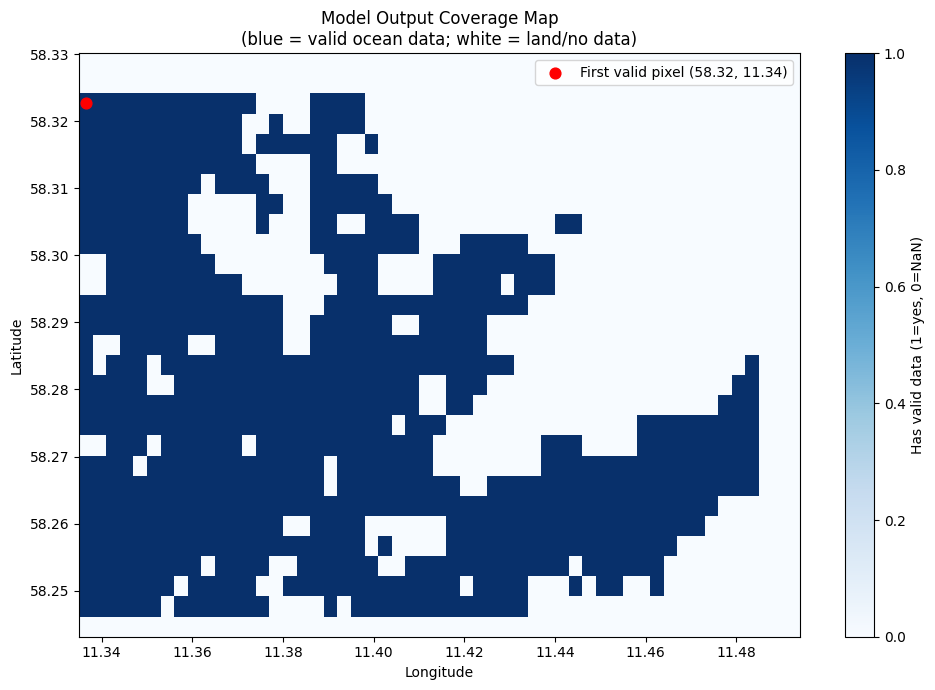

Saved: coverage_map.png


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Data coverage map
#
# This map shows WHERE the model produced valid results.
#   Blue  = valid data  (ocean pixels with complete input forcing)
#   White = NaN         (land, ice, or pixels with missing input data)
#
# HOW TO READ:
#   Pick a blue pixel's coordinates for the point-insight cell below.
#   Draw a bounding box over a group of blue pixels for the area-insight cell.
# ─────────────────────────────────────────────────────────────────────────────

data_coverage = ~ds_out['C1'].isnull().all(dim='time')

fig, ax = plt.subplots(figsize=(10, 7))
data_coverage.plot(
    ax=ax,
    cmap='Blues',
    cbar_kwargs={'label': 'Has valid data (1=yes, 0=NaN)'}
)
if valid_lat is not None:
    ax.scatter(valid_lon, valid_lat, color='red', s=60, zorder=5, label=f'First valid pixel ({valid_lat:.2f}, {valid_lon:.2f})')
    ax.legend()
ax.set_title('Model Output Coverage Map\n(blue = valid ocean data; white = land/no data)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
# plt.savefig('coverage_map.png', dpi=150)
plt.show()
print('Saved: coverage_map.png')


---
## Single-Point Insight Dashboard

Set `plot_lat` and `plot_lon` to any ocean location within your grid.
The cell below generates a **7-panel dashboard** for that single pixel showing:

1. Soft Tissue Energy trajectory over time
2. Shell Energy trajectory
3. Total Fresh Weight (commercial harvest indicator)
4. Shell Length (size indicator)
5. Driving environmental conditions (Temperature + Salinity)
6. Food availability (Chl, POC, POM, TPM)
7. A printed **summary statistics card** with growth metrics

Copy `valid_lat` / `valid_lon` from the cell above, or choose any coordinate
inside the blue area of the coverage map.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SINGLE-POINT INSIGHT REPORT
  Location : Lat 58.322635000000005°  Lon 11.336505°
  Period   : 2021-01-01  →  2021-12-31
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Nearest grid pixel: Lat 58.323°  Lon 11.337°

  ┌─────────────────────────────────────────────────────┐
  │  GROWTH SUMMARY STATISTICS                          │
  ├─────────────────────────────────────────────────────┤
  │  Soft Tissue Energy                                 │
  │    Start : 1604.46 J   End : 30138.80 J   Change: +28534.34 J  │
  │    Peak  : 30138.80 J  on 2021-12-31                 │
  ├─────────────────────────────────────────────────────┤
  │  Total Fresh Weight (TFW)                           │
  │    Start : 5.000 g   End : 91.989 g   Change: +86.989 g │
  │    Peak  : 91.989 g  on 2021-12-31                 │
  │    Daily growth rate: 0.2383 g/day               │
  ├─────────────────────────────────────────────────────┤
  

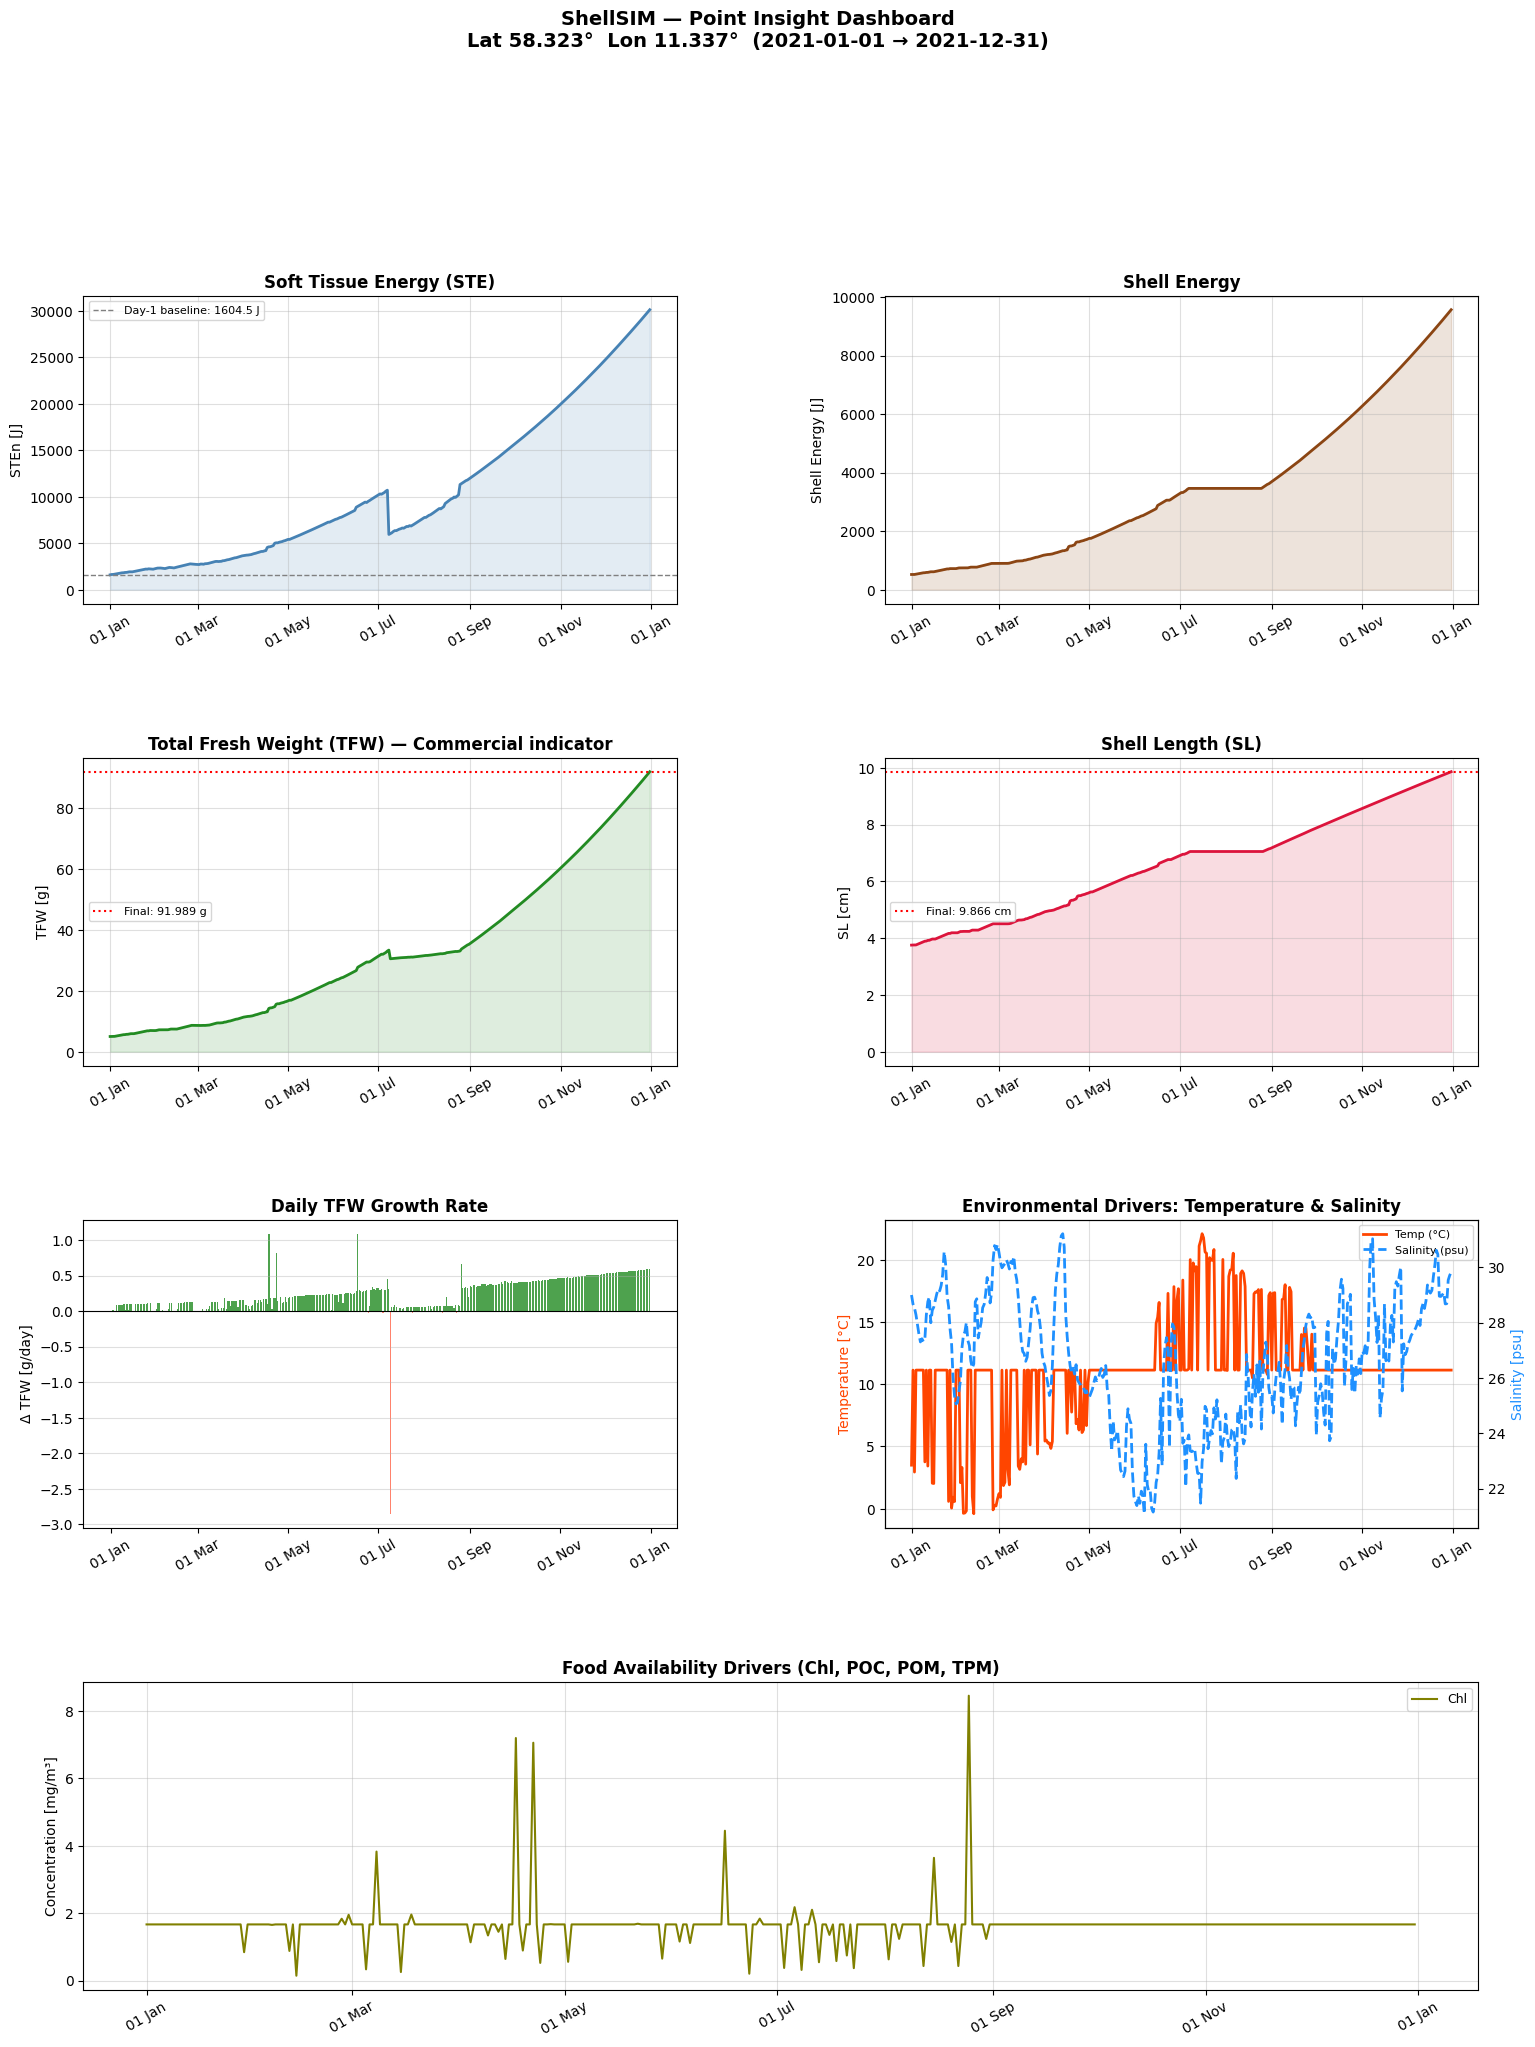


Saved: point_dashboard_58.32_11.34.png


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: ENRICHED SINGLE-POINT DASHBOARD
#
# USER INPUTS — change these two values to inspect any grid point:
plot_lat =  valid_lat   # ← latitude of the point you want to inspect
plot_lon = valid_lon    # ← longitude of the point you want to inspect
# TIP: use valid_lat / valid_lon from the cell above if unsure where to start.
# ─────────────────────────────────────────────────────────────────────────────

print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  SINGLE-POINT INSIGHT REPORT')
print(f'  Location : Lat {plot_lat}°  Lon {plot_lon}°')
print(f'  Period   : {str(ds_out.time.values[0])[:10]}  →  {str(ds_out.time.values[-1])[:10]}')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n')

try:
    # Select the nearest grid pixel to the requested lat/lon
    pt = ds_out.sel(latitude=plot_lat, longitude=plot_lon, method='nearest').load()
    actual_lat = float(pt.latitude.values)
    actual_lon = float(pt.longitude.values)
    print(f'  Nearest grid pixel: Lat {actual_lat:.3f}°  Lon {actual_lon:.3f}°\n')

    # Check if this pixel has valid data
    if pt['soft_tissue_energy'].isnull().all():
        print('⚠️  WARNING: All values at this point are NaN.')
        print('   The point may be over land or outside the valid data extent.')
        print('   Use the coverage map above to pick a blue (valid) pixel.')
    else:
        # ─── Derived growth metrics ──────────────────────────────────────────
        # We compute a set of summary statistics that tell an end user how
        # well oysters would grow at this location over the simulated period.
        times   = pd.to_datetime(pt.time.values)
        n_days  = len(times)

        ste_ts   = pt['soft_tissue_energy'].values
        shell_ts = pt['shell_energy'].values

        # ─── Regenerate TFW & SL (NOT saved in the output file) ──────────────
        # TFW (Total Fresh Weight) and SL (Shell Length) are FABM *diagnostics*
        # (Oyster/TFW, Oyster/Shell_Length), not state variables — CELL 40 only
        # wrote the 11 state variables to disk, so they are absent from ds_out.
        # We regenerate them EXACTLY for this single pixel by re-running the
        # model wrapper on the pixel's environmental forcing (cheap: 1 point).
        tfw_ts = np.full(n_days, np.nan)
        sl_ts  = np.full(n_days, np.nan)
        try:
            env_in = ds_daily.sel(latitude=actual_lat, longitude=actual_lon,
                                  method='nearest').load()
            full_out = run_fabm_at_point_full(
                env_in['temperature'].values,
                env_in['salinity'].values,
                env_in['Chl'].values,
                # env_in['POC'].values,
                # env_in['POM'].values,
                # env_in['TPM'].values,
                RUN_LOG_FILENAME,
            )
            tfw_row = VARIABLE_NAMES.index('TFW')
            sl_row  = VARIABLE_NAMES.index('SL')
            m = min(n_days, full_out.shape[1])   # guard against any length mismatch
            tfw_ts[:m] = full_out[tfw_row, :m]
            sl_ts[:m]  = full_out[sl_row,  :m]
        except Exception as _derr:
            print(f'⚠️  Could not regenerate TFW/SL from the model: {_derr}')
            print('   TFW/SL panels will be blank. Ensure ds_daily, '
                  'run_fabm_at_point_full, VARIABLE_NAMES and RUN_LOG_FILENAME '
                  'are still in memory (re-run CELLs 3, 18, 25 and 28).')

        # Growth = final value minus initial value (absolute change over period)
        ste_growth   = ste_ts[-1]   - ste_ts[0]   if not np.isnan(ste_ts[-1])   else np.nan
        shell_growth = shell_ts[-1] - shell_ts[0] if not np.isnan(shell_ts[-1]) else np.nan
        tfw_growth   = tfw_ts[-1]   - tfw_ts[0]   if not np.isnan(tfw_ts[-1])   else np.nan
        sl_growth    = sl_ts[-1]    - sl_ts[0]     if not np.isnan(sl_ts[-1])    else np.nan

        # Daily growth rate = total growth / number of days
        daily_tfw_rate = tfw_growth / n_days if not np.isnan(tfw_growth) else np.nan
        daily_sl_rate  = sl_growth  / n_days if not np.isnan(sl_growth)  else np.nan

        # Peak values
        peak_ste  = np.nanmax(ste_ts)
        peak_sl   = np.nanmax(sl_ts) if not np.all(np.isnan(sl_ts)) else np.nan
        peak_tfw  = np.nanmax(tfw_ts) if not np.all(np.isnan(tfw_ts)) else np.nan

        # Day-of-peak
        day_peak_ste = times[np.nanargmax(ste_ts)].strftime('%Y-%m-%d') if not np.all(np.isnan(ste_ts)) else 'N/A'
        day_peak_tfw = times[np.nanargmax(tfw_ts)].strftime('%Y-%m-%d') if not np.all(np.isnan(tfw_ts)) else 'N/A'

        # ─── Print summary card ───────────────────────────────────────────────
        print('  ┌─────────────────────────────────────────────────────┐')
        print('  │  GROWTH SUMMARY STATISTICS                          │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Soft Tissue Energy                                 │')
        print(f'  │    Start : {ste_ts[0]:.2f} J   End : {ste_ts[-1]:.2f} J   Change: {ste_growth:+.2f} J  │')
        print(f'  │    Peak  : {peak_ste:.2f} J  on {day_peak_ste:<20}       │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Total Fresh Weight (TFW)                           │')
        print(f'  │    Start : {tfw_ts[0]:.3f} g   End : {tfw_ts[-1]:.3f} g   Change: {tfw_growth:+.3f} g │')
        print(f'  │    Peak  : {peak_tfw:.3f} g  on {day_peak_tfw:<20}       │')
        print(f'  │    Daily growth rate: {daily_tfw_rate:.4f} g/day               │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Shell Length (SL)                                  │')
        print(f'  │    Start : {sl_ts[0]:.3f} cm  End : {sl_ts[-1]:.3f} cm  Change: {sl_growth:+.4f} cm│')
        print(f'  │    Peak  : {peak_sl:.3f} cm                                │')
        print(f'  │    Daily growth rate: {daily_sl_rate:.5f} cm/day              │')
        print('  └─────────────────────────────────────────────────────┘')

        # ─── 7-panel dashboard figure ─────────────────────────────────────────
        fig = plt.figure(figsize=(18, 22))
        gs  = GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

        # -- Panel 1: Soft Tissue Energy --
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(times, ste_ts, color='steelblue', lw=2)
        ax1.fill_between(times, ste_ts, alpha=0.15, color='steelblue')
        ax1.axhline(ste_ts[0], color='grey', ls='--', lw=1, label=f'Day-1 baseline: {ste_ts[0]:.1f} J')
        ax1.set_title('Soft Tissue Energy (STE)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('STEn [J]'); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.4)

        # -- Panel 2: Shell Energy --
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(times, shell_ts, color='saddlebrown', lw=2)
        ax2.fill_between(times, shell_ts, alpha=0.15, color='saddlebrown')
        ax2.set_title('Shell Energy', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Shell Energy [J]'); ax2.grid(True, alpha=0.4)

        # -- Panel 3: Total Fresh Weight --
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(times, tfw_ts, color='forestgreen', lw=2)
        ax3.fill_between(times, tfw_ts, alpha=0.15, color='forestgreen')
        ax3.axhline(tfw_ts[-1], color='red', ls=':', lw=1.5, label=f'Final: {tfw_ts[-1]:.3f} g')
        ax3.set_title('Total Fresh Weight (TFW) — Commercial indicator', fontsize=12, fontweight='bold')
        ax3.set_ylabel('TFW [g]'); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.4)

        # -- Panel 4: Shell Length --
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.plot(times, sl_ts, color='crimson', lw=2)
        ax4.fill_between(times, sl_ts, alpha=0.15, color='crimson')
        ax4.axhline(sl_ts[-1], color='red', ls=':', lw=1.5, label=f'Final: {sl_ts[-1]:.3f} cm')
        ax4.set_title('Shell Length (SL)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('SL [cm]'); ax4.legend(fontsize=8); ax4.grid(True, alpha=0.4)

        # -- Panel 5: Growth rates (daily delta) --
        ax5 = fig.add_subplot(gs[2, 0])
        daily_tfw_delta = np.diff(tfw_ts, prepend=tfw_ts[0])
        colors5 = ['forestgreen' if v >= 0 else 'tomato' for v in daily_tfw_delta]
        ax5.bar(times, daily_tfw_delta, color=colors5, width=0.8, alpha=0.8)
        ax5.axhline(0, color='black', lw=0.8)
        ax5.set_title('Daily TFW Growth Rate', fontsize=12, fontweight='bold')
        ax5.set_ylabel('Δ TFW [g/day]'); ax5.grid(True, axis='y', alpha=0.4)

        # -- Panel 6: Environmental drivers (T + S) --
        ax6 = fig.add_subplot(gs[2, 1])
        if 'temperature' in ds_daily and 'salinity' in ds_daily:
            env_pt = ds_daily.sel(latitude=actual_lat, longitude=actual_lon, method='nearest').load()
            ax6.plot(times, env_pt['temperature'].values, color='orangered', lw=2, label='Temp (°C)')
            ax6b = ax6.twinx()
            ax6b.plot(times, env_pt['salinity'].values, color='dodgerblue', lw=2, ls='--', label='Salinity (psu)')
            ax6b.set_ylabel('Salinity [psu]', color='dodgerblue')
        ax6.set_title('Environmental Drivers: Temperature & Salinity', fontsize=12, fontweight='bold')
        ax6.set_ylabel('Temperature [°C]', color='orangered')
        ax6.grid(True, alpha=0.4)
        lines6a, labs6a = ax6.get_legend_handles_labels()
        lines6b, labs6b = ax6b.get_legend_handles_labels()
        ax6.legend(lines6a + lines6b, labs6a + labs6b, fontsize=8)

        # -- Panel 7: Food availability --
        ax7 = fig.add_subplot(gs[3, :])
        food_colors = {'Chl': 'olive', 'POC': 'darkorange', 'POM': 'purple', 'TPM': 'teal'}
        if 'temperature' in ds_daily:
            env_pt2 = ds_daily.sel(latitude=actual_lat, longitude=actual_lon, method='nearest').load()
            for fvar, fcol in food_colors.items():
                if fvar in env_pt2:
                    ax7.plot(times, env_pt2[fvar].values, lw=1.5, label=fvar, color=fcol)
        ax7.set_title('Food Availability Drivers (Chl, POC, POM, TPM)', fontsize=12, fontweight='bold')
        ax7.set_ylabel('Concentration [mg/m³]'); ax7.legend(fontsize=9); ax7.grid(True, alpha=0.4)

        # Shared x-axis formatting
        for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
            ax.tick_params(axis='x', rotation=30)

        fig.suptitle(
            f'ShellSIM — Point Insight Dashboard\nLat {actual_lat:.3f}°  Lon {actual_lon:.3f}°  '
            f'({str(times[0].date())} → {str(times[-1].date())})',
            fontsize=14, fontweight='bold', y=1.01
        )
        # plt.savefig(f'point_dashboard_{actual_lat:.2f}_{actual_lon:.2f}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'\nSaved: point_dashboard_{actual_lat:.2f}_{actual_lon:.2f}.png')

except Exception as e:
    print(f'\n❌ ERROR loading data for point ({plot_lat}, {plot_lon}): {e}')
    print("   Make sure 'ds_out' is loaded and the coordinate is within the grid.")


---
## Bounding-Box (Area) Insight Dashboard

Users draw a rectangle on a map, set a start/end date, and want to know:
**"How does oyster growth look across the whole area I selected?"**

This cell produces a **multi-panel area report** containing:

| Panel | What it shows | Why it matters |
|---|---|---|
| Spatial mean maps | Average STE, TFW, SL over time | Identify the best-performing zones |
| Area-mean time series | How the 'average oyster' in the box grew | Overall growth trend for the region |
| Spatial variability map | Std-dev of TFW across pixels | Highlights patchy vs. uniform conditions |
| Growth potential map | Final TFW map | Where harvest yield would be highest |
| Histogram | Distribution of final TFW across pixels | Is growth broadly similar or highly skewed? |
| Summary statistics table | Min/max/mean/percentiles per variable | At-a-glance numbers for the drawn area |

**HOW TO USE:**
1. Set `bbox_user` to your drawn bounding box `(min_lon, min_lat, max_lon, max_lat)`.
2. Optionally narrow the time window with `bbox_time_start` / `bbox_time_end`.
3. Run the cell.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AREA INSIGHT REPORT
  Bounding box   : (11.336505, 58.244635) → (11.489554, 58.325851)
  Grid cells     : 28 lat × 52 lon = 1456 pixels
  Time steps     : 365  (2021-01-01 → 2021-12-31)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  AREA STATISTICS (across all pixels, time-mean values)
  ────────────────────────────────────────────────────────────────────────────────
  Soft Tissue Energy (STE)     min=179.506 J  mean=24826.885 J  max=433451.125 J  p25=14713.916  p75=25703.622
  Total Fresh Weight (TFW)     min=4.565 g  mean=81.056 g  max=1787.438 g  p25=46.635  p75=81.316
  Shell Length (SL)            min=3.757 cm  mean=8.224 cm  max=24.890 cm  p25=7.373  p75=8.722
  Final TFW (last day)         min=11.295 g  mean=222.864 g  max=2502.019 g  p25=132.734  p75=239.942

  Valid ocean pixels : 727 / 1456  (49.9%)

  Area-mean TFW change : +217.8640 g  (0.59689 g/day)
  Area-mean SL change  : +8.89215 cm (0.024

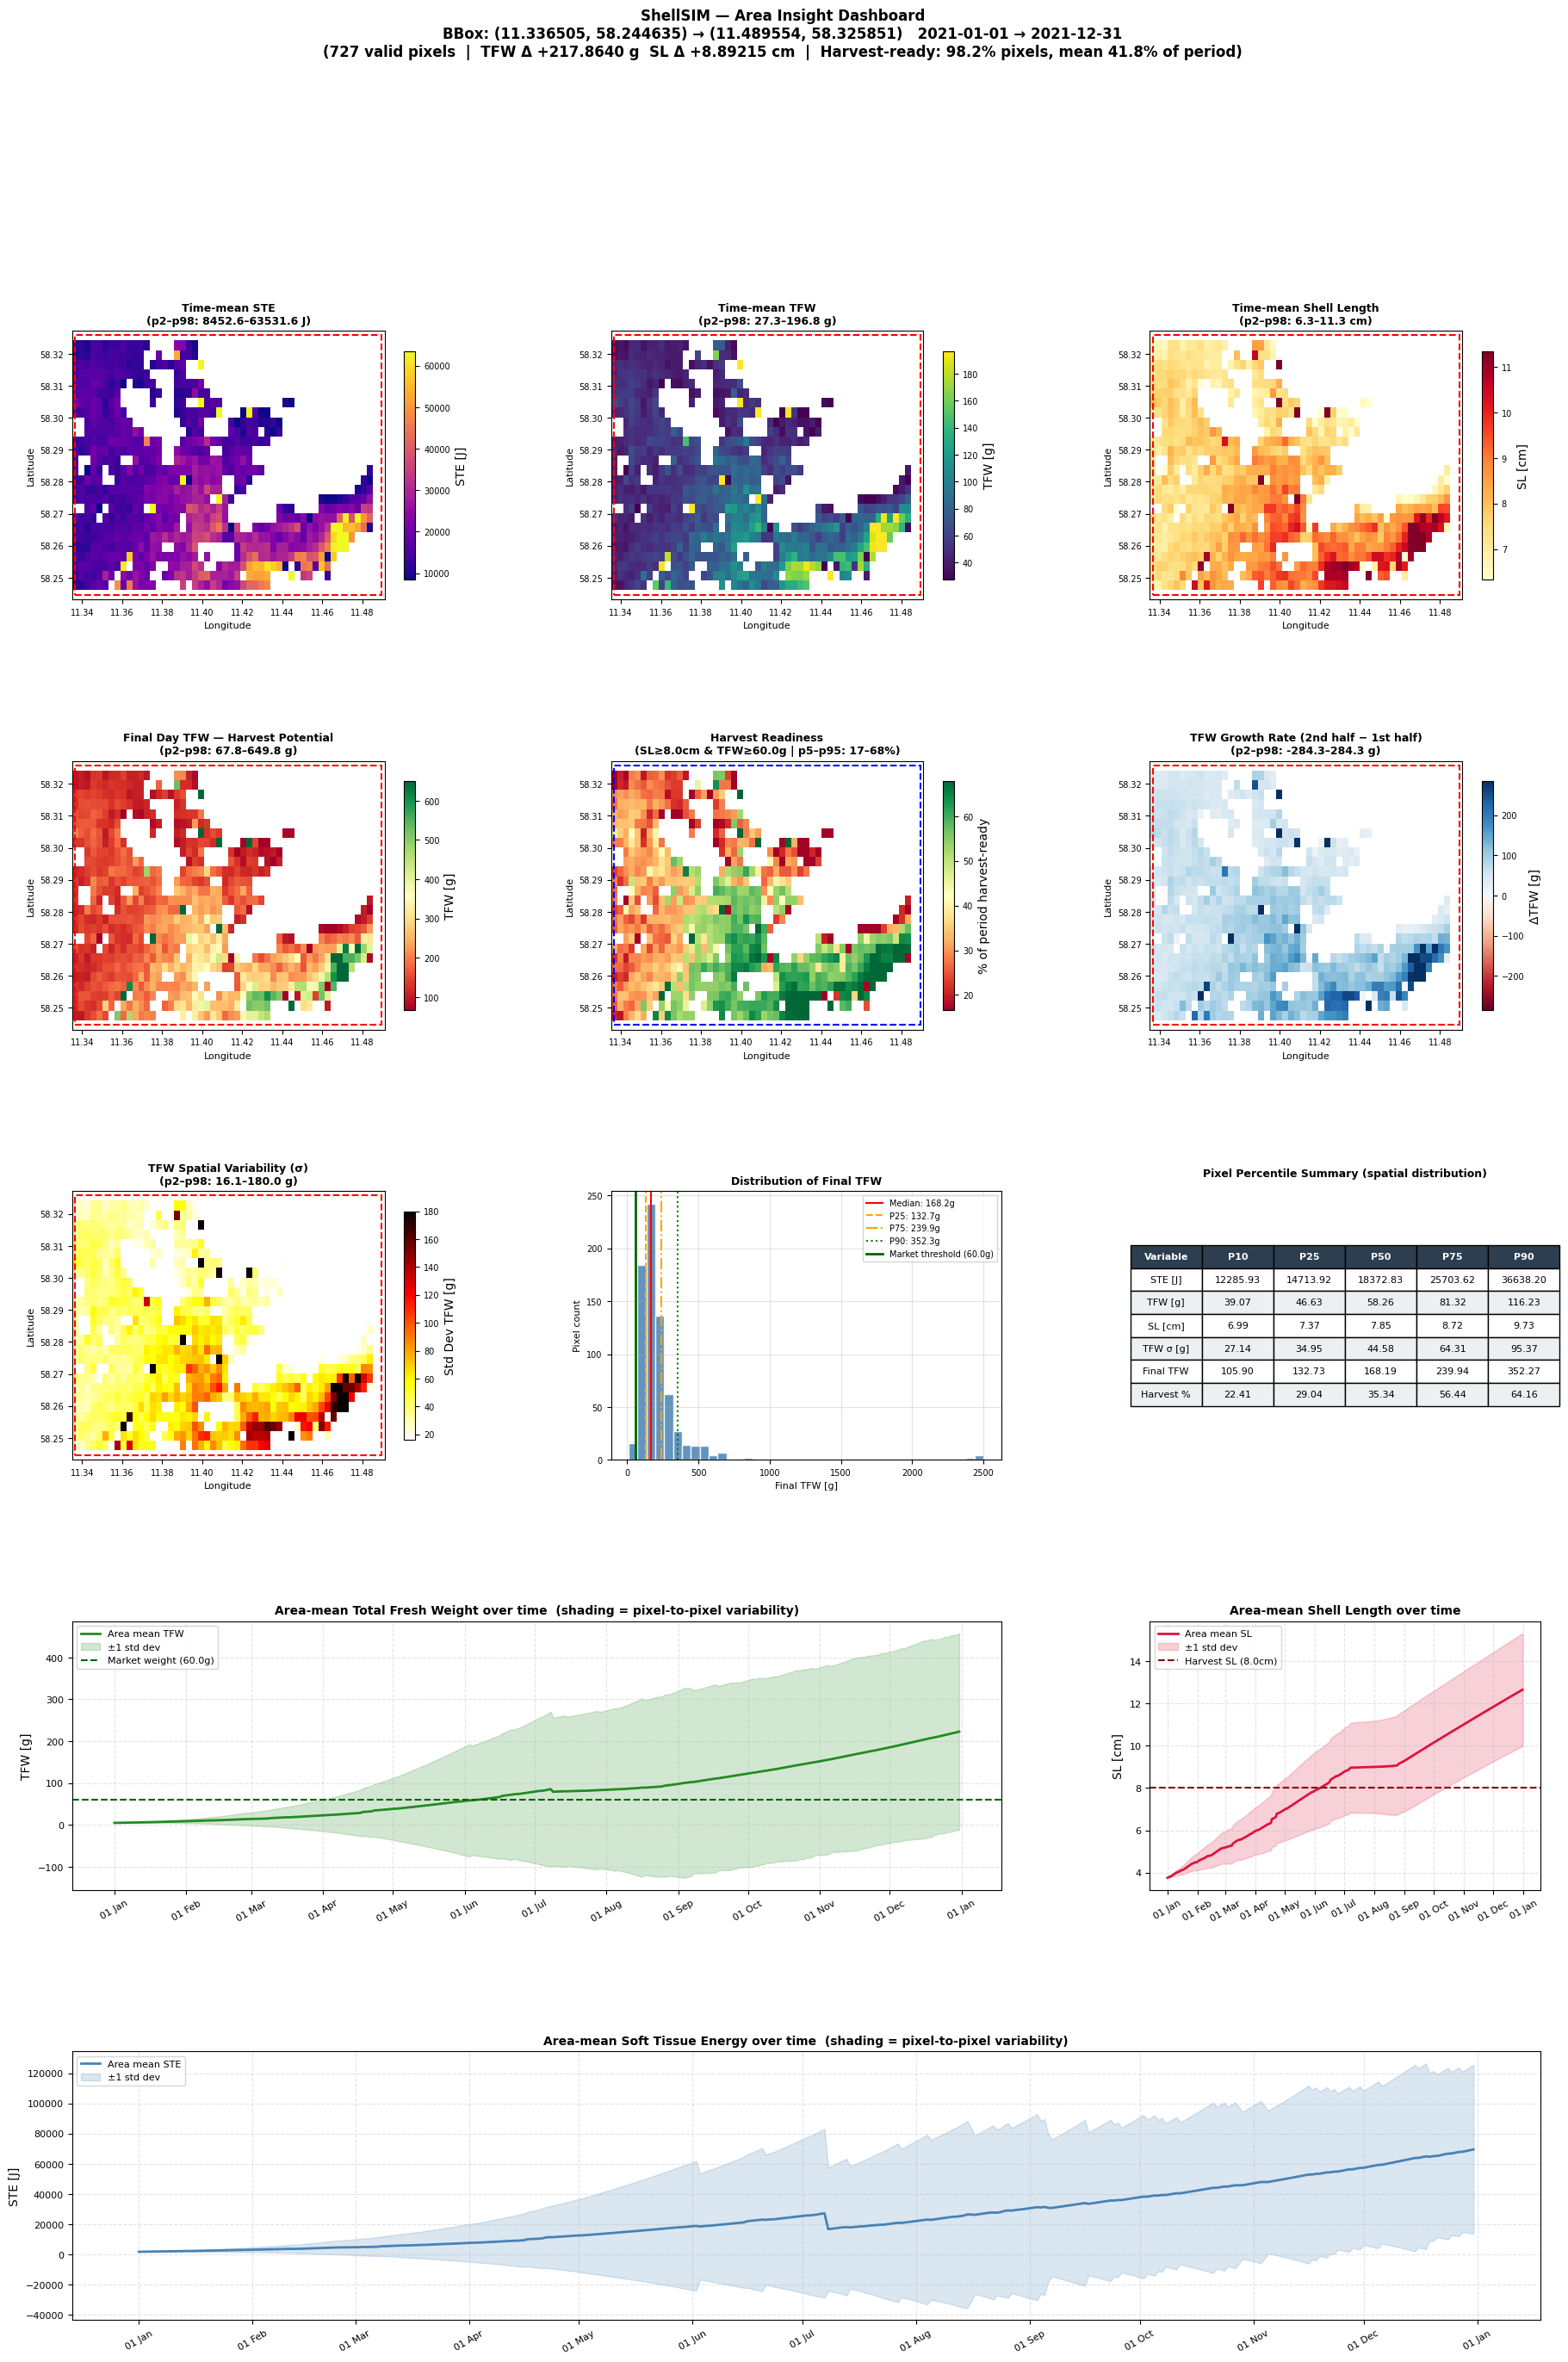


Saved: area_dashboard_bbox.png


In [49]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: BOUNDING-BOX AREA INSIGHT DASHBOARD  (optimised)
#
# Changes vs original:
#   • All spatial maps use p2–p98 percentile-stretched vmin/vmax
#   • Colormaps chosen for perceptual distinction:
#       STE  → plasma   (dark→bright, great for energy magnitudes)
#       TFW  → viridis  (perceptually uniform, science standard)
#       SL   → YlOrRd   (warm ramp, matches "growth heat")
#       Var  → hot_r    (dark = low noise, bright = high risk zones)
#       FinalTFW → RdYlGn (harvest context: red=not ready, green=ready)
#   • NEW panel: Harvest Readiness map (fraction of period both thresholds met)
#   • NEW panel: TFW Growth-Rate map (second-half mean minus first-half mean)
#   • NEW panel: Pixel-level percentile summary table (P10/P25/P50/P75/P90)
#   • Time-series plots add monthly grid lines and a harvest threshold line
# ═══════════════════════════════════════════════════════════════════════════════

# ── USER INPUTS ───────────────────────────────────────────────────────────────
bbox_user       = bbox        # (min_lon, min_lat, max_lon, max_lat)
bbox_time_start = None        # e.g. '2021-06-01' or None
bbox_time_end   = None        # e.g. '2021-12-31' or None
# ─────────────────────────────────────────────────────────────────────────────

# ── Load & subset ─────────────────────────────────────────────────────────────
OUTPUT_FILE = "gridded_oyster_output_ALL_STATES_batched.nc"
ds_out = xr.open_dataset(OUTPUT_FILE, decode_timedelta=False)
ds_out = ds_out.where(ds_out > -90)

if ds_out.latitude[0] > ds_out.latitude[-1]:
    lat_slice = slice(max_lat, min_lat)
else:
    lat_slice = slice(min_lat, max_lat)

if ds_out.longitude[0] > ds_out.longitude[-1]:
    lon_slice = slice(max_lon, min_lon)
else:
    lon_slice = slice(min_lon, max_lon)

ds_bbox = ds_out.sel(latitude=lat_slice, longitude=lon_slice)

if bbox_time_start is not None and bbox_time_end is not None:
    ds_bbox = ds_bbox.sel(time=slice(bbox_time_start, bbox_time_end))

ds_bbox = ds_bbox.compute()

n_lat    = ds_bbox.sizes.get('latitude',  ds_bbox.sizes.get('lat',  0))
n_lon    = ds_bbox.sizes.get('longitude', ds_bbox.sizes.get('lon',  0))
n_t      = ds_bbox.sizes.get('time', 0)
n_pixels = n_lat * n_lon
bbox_times = pd.to_datetime(ds_bbox.time.values)

print(f'\n{"━"*60}')
print(f'  AREA INSIGHT REPORT')
print(f'  Bounding box   : ({min_lon}, {min_lat}) → ({max_lon}, {max_lat})')
print(f'  Grid cells     : {n_lat} lat × {n_lon} lon = {n_pixels} pixels')
print(f'  Time steps     : {n_t}  ({str(bbox_times[0].date())} → {str(bbox_times[-1].date())})')
print(f'{"━"*60}\n')

has_tfw = 'TFW' in ds_bbox
has_sl  = 'SL'  in ds_bbox
if not has_tfw or not has_sl:
    print('⚠️  TFW and/or SL not found in output file.')
    raise RuntimeError('Missing TFW or SL in output file.')

# ── Pre-compute all spatial / time fields ─────────────────────────────────────
area_mean = ds_bbox[['soft_tissue_energy', 'shell_energy', 'TFW', 'SL']].mean(
    dim=['latitude', 'longitude'], skipna=True)
area_std  = ds_bbox[['soft_tissue_energy', 'shell_energy', 'TFW', 'SL']].std(
    dim=['latitude', 'longitude'], skipna=True)

spatial_mean_ste  = ds_bbox['soft_tissue_energy'].mean(dim='time', skipna=True)
spatial_mean_tfw  = ds_bbox['TFW'].mean(dim='time', skipna=True)
spatial_mean_sl   = ds_bbox['SL'].mean(dim='time',  skipna=True)
spatial_std_tfw   = ds_bbox['TFW'].std(dim='time',  skipna=True)
spatial_final_tfw = ds_bbox['TFW'].isel(time=-1)

# NEW: TFW growth-rate map (second half mean − first half mean)
mid = n_t // 2
spatial_growth_tfw = (
    ds_bbox['TFW'].isel(time=slice(mid, None)).mean(dim='time', skipna=True) -
    ds_bbox['TFW'].isel(time=slice(None, mid)).mean(dim='time', skipna=True)
)

# NEW: Harvest readiness fraction
sl_arr  = ds_bbox['SL'].values   # (lat, lon, time) after compute
tfw_arr = ds_bbox['TFW'].values
both_ready   = (sl_arr >= HARVEST_SL_CM) & (tfw_arr >= MARKET_WEIGHT_G)
harvest_frac = np.nansum(both_ready, axis=2) / n_t
harvest_frac[np.all(np.isnan(sl_arr), axis=2)] = np.nan

valid_pixels   = harvest_frac[~np.isnan(harvest_frac)]
pct_area_ready = 100.0 * np.mean(valid_pixels > 0) if len(valid_pixels) > 0 else 0.0
mean_frac      = 100.0 * np.nanmean(valid_pixels)  if len(valid_pixels) > 0 else 0.0

# ── Summary stats ─────────────────────────────────────────────────────────────
def area_stats(da, name, units):
    vals = da.values.flatten()
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return f'  {name:<28} all NaN'
    return (f'  {name:<28} min={vals.min():.3f} {units}  '
            f'mean={vals.mean():.3f} {units}  '
            f'max={vals.max():.3f} {units}  '
            f'p25={np.percentile(vals, 25):.3f}  '
            f'p75={np.percentile(vals, 75):.3f}')

print('  AREA STATISTICS (across all pixels, time-mean values)')
print('  ' + '─' * 80)
print(area_stats(spatial_mean_ste,  'Soft Tissue Energy (STE)', 'J'))
print(area_stats(spatial_mean_tfw,  'Total Fresh Weight (TFW)', 'g'))
print(area_stats(spatial_mean_sl,   'Shell Length (SL)',        'cm'))
print(area_stats(spatial_final_tfw, 'Final TFW (last day)',     'g'))

valid_pixel_count = int((~np.isnan(spatial_final_tfw.values)).sum())
print(f'\n  Valid ocean pixels : {valid_pixel_count} / {n_pixels}  ({100*valid_pixel_count/max(n_pixels,1):.1f}%)')

tfw_vals = area_mean['TFW'].values
sl_vals  = area_mean['SL'].values
area_tfw_growth = float(tfw_vals[-1] - tfw_vals[0]) if not np.isnan(tfw_vals[-1]) else np.nan
area_sl_growth  = float(sl_vals[-1]  - sl_vals[0])  if not np.isnan(sl_vals[-1])  else np.nan
print(f'\n  Area-mean TFW change : {area_tfw_growth:+.4f} g  ({area_tfw_growth/n_t:.5f} g/day)')
print(f'  Area-mean SL change  : {area_sl_growth:+.5f} cm ({area_sl_growth/n_t:.6f} cm/day)')
print(f'  Harvest readiness    : {pct_area_ready:.1f}% of pixels ever ready  |  mean {mean_frac:.1f}% of period')
print(f'{"━"*60}')

# ═══════════════════════════════════════════════════════════════════════════════
# HELPER: percentile-aware pcolormesh
# ═══════════════════════════════════════════════════════════════════════════════
def pclip(arr, p_lo=2, p_hi=98):
    """Return (vmin, vmax) clipped to percentiles, ignoring NaN."""
    flat = arr[~np.isnan(arr)] if hasattr(arr, '__len__') else arr
    if len(flat) == 0:
        return 0, 1
    return float(np.percentile(flat, p_lo)), float(np.percentile(flat, p_hi))

def plot_map(ax, da, title, cmap, units, cbar_label=None, p_lo=2, p_hi=98,
             diverging=False, vcenter=None):
    """Plot a spatial map with percentile-stretched colourmap."""
    try:
        lat_dim = 'latitude' if 'latitude' in da.dims else 'lat'
        lon_dim = 'longitude' if 'longitude' in da.dims else 'lon'
        vals = da.values
        vmin, vmax = pclip(vals, p_lo, p_hi)

        if diverging and vcenter is not None:
            # Symmetric stretch around vcenter for growth maps
            half = max(abs(vmax - vcenter), abs(vcenter - vmin))
            vmin, vmax = vcenter - half, vcenter + half

        im = ax.pcolormesh(
            da[lon_dim].values, da[lat_dim].values, vals,
            cmap=cmap, shading='auto', vmin=vmin, vmax=vmax
        )
        cb = plt.colorbar(im, ax=ax, shrink=0.85, label=cbar_label or units)
        cb.ax.tick_params(labelsize=7)
        ax.set_title(f'{title}\n(p{p_lo}–p{p_hi}: {vmin:.1f}–{vmax:.1f} {units})',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=8)
        ax.set_ylabel('Latitude',  fontsize=8)
        ax.tick_params(labelsize=7)
        # BBox outline
        rect = mpatches.Rectangle(
            (min_lon, min_lat), max_lon - min_lon, max_lat - min_lat,
            linewidth=1.5, edgecolor='red', facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes)

def style_ts(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.35, linestyle='--')

# ═══════════════════════════════════════════════════════════════════════════════
# LAYOUT: 5 rows × 3 cols
#   Row 0 : STE map | TFW map          | SL map
#   Row 1 : TFW Var | Final TFW        | TFW growth-rate (NEW)
#   Row 2 : Harvest readiness map (NEW)| Final-TFW histogram | Percentile table (NEW)
#   Row 3 : TFW time series (span 2)   | SL time series
#   Row 4 : STE time series (full width)
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 30))
gs  = GridSpec(5, 3, figure=fig, hspace=0.60, wspace=0.38)

# ── ROW 0: Time-mean spatial maps ────────────────────────────────────────────
plot_map(fig.add_subplot(gs[0, 0]), spatial_mean_ste, 'Time-mean STE',
         'plasma',  'J',  cbar_label='STE [J]')
plot_map(fig.add_subplot(gs[0, 1]), spatial_mean_tfw, 'Time-mean TFW',
         'viridis', 'g',  cbar_label='TFW [g]')
plot_map(fig.add_subplot(gs[0, 2]), spatial_mean_sl,  'Time-mean Shell Length',
         'YlOrRd',  'cm', cbar_label='SL [cm]')

# ── ROW 1: Harvest readiness  / Final / Growth ──────────────────────────────────────
# Harvest readiness map
ax_hr = fig.add_subplot(gs[1, 1])
lon_grid, lat_grid = np.meshgrid(ds_bbox.longitude.values, ds_bbox.latitude.values)
hr_vals = harvest_frac * 100.0
hr_vmin, hr_vmax = pclip(hr_vals[~np.isnan(hr_vals)], 5, 95)
im_hr = ax_hr.pcolormesh(lon_grid, lat_grid, hr_vals,
                          cmap='RdYlGn', shading='auto',
                          vmin=hr_vmin, vmax=hr_vmax)
cb_hr = plt.colorbar(im_hr, ax=ax_hr, shrink=0.85, label='% of period harvest-ready')
cb_hr.ax.tick_params(labelsize=7)
ax_hr.set_title(
    f'Harvest Readiness\n(SL≥{HARVEST_SL_CM}cm & TFW≥{MARKET_WEIGHT_G}g | '
    f'p5–p95: {hr_vmin:.0f}–{hr_vmax:.0f}%)',
    fontsize=9, fontweight='bold')
ax_hr.set_xlabel('Longitude', fontsize=8)
ax_hr.set_ylabel('Latitude',  fontsize=8)
ax_hr.tick_params(labelsize=7)
rect = mpatches.Rectangle(
    (min_lon, min_lat), max_lon - min_lon, max_lat - min_lat,
    linewidth=1.5, edgecolor='blue', facecolor='none', linestyle='--')
ax_hr.add_patch(rect)


plot_map(fig.add_subplot(gs[1, 0]), spatial_final_tfw, 'Final Day TFW — Harvest Potential',
         'RdYlGn',  'g',  cbar_label='TFW [g]')
plot_map(fig.add_subplot(gs[1, 2]), spatial_growth_tfw, 'TFW Growth Rate (2nd half − 1st half)',
         'RdBu',   'g',  cbar_label='ΔTFW [g]',
         diverging=True, vcenter=0.0)

# ── ROW 2:  Variability | Histogram | Percentile table ──────────────────

plot_map(fig.add_subplot(gs[2, 0]), spatial_std_tfw,   'TFW Spatial Variability (σ)',
         'hot_r',   'g',  cbar_label='Std Dev TFW [g]')

# Final TFW histogram
ax_hist = fig.add_subplot(gs[2, 1])
final_tfw_flat = spatial_final_tfw.values.flatten()
final_tfw_flat = final_tfw_flat[~np.isnan(final_tfw_flat)]
if len(final_tfw_flat) > 0:
    ax_hist.hist(final_tfw_flat, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    for p, c, ls, lbl in [
        (50, 'red',    '-',  f'Median: {np.percentile(final_tfw_flat,50):.1f}g'),
        (25, 'orange', '--', f'P25: {np.percentile(final_tfw_flat,25):.1f}g'),
        (75, 'orange', '-.', f'P75: {np.percentile(final_tfw_flat,75):.1f}g'),
        (90, 'green',  ':',  f'P90: {np.percentile(final_tfw_flat,90):.1f}g'),
    ]:
        ax_hist.axvline(np.percentile(final_tfw_flat, p), color=c, lw=1.5, ls=ls, label=lbl)
    if MARKET_WEIGHT_G:
        ax_hist.axvline(MARKET_WEIGHT_G, color='darkgreen', lw=2, ls='-',
                        label=f'Market threshold ({MARKET_WEIGHT_G}g)')
    ax_hist.set_xlabel('Final TFW [g]', fontsize=8)
    ax_hist.set_ylabel('Pixel count',   fontsize=8)
    ax_hist.set_title('Distribution of Final TFW', fontsize=9, fontweight='bold')
    ax_hist.legend(fontsize=7)
    ax_hist.grid(True, alpha=0.35)
    ax_hist.tick_params(labelsize=7)
else:
    ax_hist.text(0.5, 0.5, 'No valid TFW data', ha='center', va='center',
                 transform=ax_hist.transAxes)

# NEW: Pixel-level percentile summary table
ax_tbl = fig.add_subplot(gs[2, 2])
ax_tbl.axis('off')
vars_for_table = {
    'STE [J]':     spatial_mean_ste.values.flatten(),
    'TFW [g]':     spatial_mean_tfw.values.flatten(),
    'SL [cm]':     spatial_mean_sl.values.flatten(),
    'TFW σ [g]':   spatial_std_tfw.values.flatten(),
    'Final TFW':   spatial_final_tfw.values.flatten(),
    'Harvest %':   harvest_frac.flatten() * 100,
}
rows, cols = [], ['Variable', 'P10', 'P25', 'P50', 'P75', 'P90']
for name, arr in vars_for_table.items():
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        rows.append([name, *['—']*5])
    else:
        rows.append([name] + [f'{np.percentile(arr, p):.2f}' for p in [10, 25, 50, 75, 90]])
tbl = ax_tbl.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#ecf0f1')
ax_tbl.set_title('Pixel Percentile Summary (spatial distribution)',
                 fontsize=9, fontweight='bold', pad=12)

# ── ROW 3: TFW & SL time series ──────────────────────────────────────────────
ax_ts1 = fig.add_subplot(gs[3, :2])
ax_ts1.plot(bbox_times, area_mean['TFW'].values, color='forestgreen', lw=2, label='Area mean TFW')
ax_ts1.fill_between(
    bbox_times,
    area_mean['TFW'].values - area_std['TFW'].values,
    area_mean['TFW'].values + area_std['TFW'].values,
    alpha=0.2, color='forestgreen', label='±1 std dev')
if MARKET_WEIGHT_G:
    ax_ts1.axhline(MARKET_WEIGHT_G, color='darkgreen', lw=1.5, ls='--',
                   label=f'Market weight ({MARKET_WEIGHT_G}g)')
ax_ts1.set_title('Area-mean Total Fresh Weight over time  (shading = pixel-to-pixel variability)',
                 fontsize=10, fontweight='bold')
ax_ts1.set_ylabel('TFW [g]')
ax_ts1.legend(fontsize=8)
style_ts(ax_ts1)

ax_ts2 = fig.add_subplot(gs[3, 2])
ax_ts2.plot(bbox_times, area_mean['SL'].values, color='crimson', lw=2, label='Area mean SL')
ax_ts2.fill_between(
    bbox_times,
    area_mean['SL'].values - area_std['SL'].values,
    area_mean['SL'].values + area_std['SL'].values,
    alpha=0.2, color='crimson', label='±1 std dev')
if HARVEST_SL_CM:
    ax_ts2.axhline(HARVEST_SL_CM, color='darkred', lw=1.5, ls='--',
                   label=f'Harvest SL ({HARVEST_SL_CM}cm)')
ax_ts2.set_title('Area-mean Shell Length over time', fontsize=10, fontweight='bold')
ax_ts2.set_ylabel('SL [cm]')
ax_ts2.legend(fontsize=8)
style_ts(ax_ts2)

# ── ROW 4: STE time series ────────────────────────────────────────────────────
ax_ste = fig.add_subplot(gs[4, :])
ax_ste.plot(bbox_times, area_mean['soft_tissue_energy'].values,
            color='steelblue', lw=2, label='Area mean STE')
ax_ste.fill_between(
    bbox_times,
    area_mean['soft_tissue_energy'].values - area_std['soft_tissue_energy'].values,
    area_mean['soft_tissue_energy'].values + area_std['soft_tissue_energy'].values,
    alpha=0.2, color='steelblue', label='±1 std dev')
ax_ste.set_title('Area-mean Soft Tissue Energy over time  (shading = pixel-to-pixel variability)',
                 fontsize=10, fontweight='bold')
ax_ste.set_ylabel('STE [J]')
ax_ste.legend(fontsize=8)
style_ts(ax_ste)

# ── Super-title ───────────────────────────────────────────────────────────────
tfw_growth_str = f'{area_tfw_growth:+.4f} g' if not np.isnan(area_tfw_growth) else 'N/A'
sl_growth_str  = f'{area_sl_growth:+.5f} cm' if not np.isnan(area_sl_growth)  else 'N/A'
fig.suptitle(
    f'ShellSIM — Area Insight Dashboard\n'
    f'BBox: ({min_lon}, {min_lat}) → ({max_lon}, {max_lat})   '
    f'{str(bbox_times[0].date())} → {str(bbox_times[-1].date())}\n'
    f'({valid_pixel_count} valid pixels  |  TFW Δ {tfw_growth_str}  SL Δ {sl_growth_str}  |  '
    f'Harvest-ready: {pct_area_ready:.1f}% pixels, mean {mean_frac:.1f}% of period)',
    fontsize=12, fontweight='bold', y=1.005
)

plt.savefig('area_dashboard_bbox.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: area_dashboard_bbox.png')

---
## Bounding-Box (Area) Insight Dashboard
| Panel | What it shows | Why it matters |
|---|---|---|
| Spatial mean maps | Average STE, TFW, SL over time | Identify the best-performing zones |
| Area-mean time series | How the 'average oyster' in the box grew | Overall growth trend for the region |
| Spatial variability map | Std-dev of TFW across pixels | Highlights patchy vs. uniform conditions |
| Growth potential map | Final TFW map | Where harvest yield would be highest |
| Histogram | Distribution of final TFW across pixels | Is growth broadly similar or highly skewed? |
| Summary statistics table | Min/max/mean/percentiles per variable | At-a-glance numbers for the drawn area |

